In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm

import statsmodels.stats.power as smp
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm

# reload utils
import importlib
importlib.reload(utils)


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

seq_length = 7 #Length of sequences

windowSizes = [1, 2, 3, 7]

fingers = ['1', '2', '3', '4', '5'] #mapping of fingers to numbers

iti = 3000   #Inter trial interval
hand = 2 #left or right hand

# total_sub_num = 10
sub_nums = [1,2,3, 4, 5, 6, 7, 8, 9, 10, 11]

num_trained_seq = 1

total_sub_num = 20
num_sessions = 4
num_blocks_per_session = 4

num_baseline_blocks = 1
num_trials_per_block = 40

percentile_low = 45; percentile_high = 80; percentile_low_super = 10; #percentiles for categorizing ETs




In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker

def set_figure_style(scale="1col"):
    """
    Set figure styling based on publication constraints.
    
    Parameters:
        scale (str): Scale of the figure, choose from "1col", "1.5col", "2col".
                     - "1col" for 8.5cm
                     - "1.5col" for 11.6cm
                     - "2col" for 17.6cm
    """
    # Define width options in cm
    widths = {"1col": 7.62, "1.5col": 11.6, "2col": 16.5}
    
    if scale not in widths:
        raise ValueError("Invalid scale. Choose from '1col', '1.5col', or '2col'.")
    
    # Convert width from cm to inches (1 cm = 0.393701 inches)
    width_in = widths[scale] * 0.393701
    
    # Set figure size (width, height)
    # Assuming height proportional to width (Golden Ratio)
    golden_ratio = (5**0.5 - 1) / 2
    rcParams["figure.figsize"] = (width_in, width_in * golden_ratio)
    
    # Set font sizes
    rcParams["font.size"] = 10  # General font size
    # rcParams["font.size"] = 20  # General font size
    rcParams["axes.titlesize"] = 12  # Figure title
    # rcParams["axes.titlesize"] = 26  # Figure title
    rcParams["axes.labelsize"] = 9  # Axis main label
    # rcParams["axes.labelsize"] = 22  # Axis main label
    rcParams["xtick.labelsize"] = 7  # Tick labels
    # rcParams["xtick.labelsize"] = 16  # Tick labels
    rcParams["ytick.labelsize"] = 7
    # rcParams["ytick.labelsize"] = 16
    rcParams["legend.fontsize"] = 8  # Legend entries
    # rcParams["legend.fontsize"] = 20  # Legend entries
    rcParams["figure.titleweight"] = "bold"
    
    # Set stroke width
    rcParams["axes.linewidth"] = 0.75
    # rcParams["axes.linewidth"] = 1.5

    # rcParams["lines.linewidth"] = 3
    
    rcParams["xtick.major.width"] = 0.75
    # rcParams["xtick.major.width"] = 1.5
    rcParams["ytick.major.width"] = 0.75
    # rcParams["ytick.major.width"] = 1.5

    
    # Subpanel lettering size
    rcParams["text.usetex"] = False  # Set to True if using LaTeX
    rcParams["axes.formatter.use_mathtext"] = True  # Math text for scientific notation

def add_subpanel_label(ax, label, fontsize=20, position=(-0.1, 1.05)):
    """
    Add a subpanel label (e.g., 'a', 'b') to a subplot.
    
    Parameters:
        ax (Axes): Matplotlib Axes object.
        label (str): The label text.
        fontsize (int): Font size for the label.
        position (tuple): Position of the label in axes coordinates.
    """
    ax.text(position[0], position[1], label, transform=ax.transAxes, 
            fontsize=fontsize, fontweight="bold", va="top", ha="left")

###
set_figure_style(scale="1col")

sns.set_palette("colorblind")


In [3]:
subjs = pd.read_csv(utils.path_misc+'subjs.csv', sep = '\t')

# exclude first block 
subjs = subjs[subjs['BN'] > 1]
rank_df = pd.DataFrame(index = subjs.index)
for subnum, data in subjs.groupby('SubNum'):
    data = data.sort_values(by = ['BN', 'TN'])
    data['N'] = data.groupby(['BN', 'TN']).ngroup() + 1
    rank_df.loc[data.index, 'N'] = data['N'].astype('int')
        

subjs['N'] = rank_df['N'].astype('int')
subjs = subjs[subjs['isCross'] == 0]

# adding day column to subjs
day1_blocks =list(range(2, num_blocks_per_session + 2))  # Blocks 2 to 5
day2_blocks = list(range(num_blocks_per_session + 2, num_blocks_per_session * 2 + 2))  # Blocks 6 to 9
day3_blocks = list(range(num_blocks_per_session * 2 + 2, num_blocks_per_session * 3 + 2))  # Blocks 10 to 13
day4_blocks = list(range(num_blocks_per_session * 3 + 2, num_blocks_per_session * 4 + 2))  # Blocks 14 to 17

subjs['day'] = 0
subjs.loc[subjs['BN'].isin(day1_blocks), 'day'] = 1
subjs.loc[subjs['BN'].isin(day2_blocks), 'day'] = 2
subjs.loc[subjs['BN'].isin(day3_blocks), 'day'] = 3
subjs.loc[subjs['BN'].isin(day4_blocks), 'day'] = 4

subjs['zone'] = subjs['zone'].map({0:0, 1:4, 2:3, 3:2, 4:1})


forces_wide = pd.read_csv(utils.path_misc+'forces_wide.csv', sep = '\t')
# create a force_vector column that is an np array of concatenated forces columns
forces_wide['force_vector'] = forces_wide[[col for col in forces_wide.columns if col.startswith('force_')]].apply(lambda x: np.array(x), axis=1)




In [4]:
# subjs_forces = pd.read_csv(utils.path_misc+'subjs_force_train.csv', sep = '\t')

# # for each finger press, calculate it's press time (passing 1.5 N) and depress time (passing 0.8 N on the way down)
# # then calculate the peak force between the press time and depress time
# press_threshold = 1.5
# depress_threshold = 0.8
# peak_forces = []
# for subind, subdata in tqdm(subjs_forces.groupby('SubNum')):
#     for bn, block_data in subdata.groupby('BN'):
#         for tn, trial_data in block_data.groupby('TN'):
#             trial_data = trial_data.sort_values(by='time')
#             press_time = None
#             depress_time = None
#             peak_force = None
#             for finger in range(1, 6):
#                 finger_data = trial_data[trial_data['Force_Number'] == f'force{finger}R']
#                 while True:
#                     # find press times (crossing 1.5 N)
#                     pressed = finger_data[finger_data['Force_Value'] >= press_threshold]
#                     if pressed.empty:
#                         break
#                     press_time = pressed['time'].values[0]
#                     # find depress times (crossing 0.8 N after press time)
#                     depressed = finger_data[(finger_data['Force_Value'] <= depress_threshold) & (finger_data['time'] > press_time)]
#                     if depressed.empty:
#                         depress_time = finger_data['time'].values[-1]
#                     else:
#                         depress_time = depressed['time'].values[0]
#                     # find peak force between press time and depress time
#                     peak_force = finger_data[(finger_data['time'] >= press_time) & (finger_data['time'] <= depress_time)]['Force_Value'].max()
#                     # remove the processed data
#                     finger_data = finger_data[finger_data['time'] > depress_time]
#                     peak_forces.append({
#                         'SubNum': subind,
#                         'BN': bn,
#                         'TN': tn,
#                         'Finger': finger,
#                         'Press_Time': press_time,
#                         'Depress_Time': depress_time,
#                         'Peak_Force': peak_force,
#                         'points': trial_data['points'].values[0],
#                         'ET': trial_data['ET'].values[0], 
#                         'zone': trial_data['zone'].values[0],
#                         'N': trial_data['N'].values[0]
#                     })

# peak_forces = pd.DataFrame(peak_forces)
                
# # check the number of rows per trial
# peak_forces.groupby(['SubNum', 'BN', 'TN']).size().value_counts()

# # drop rows with not seq length peaks
# peak_forces = peak_forces.groupby(['SubNum', 'BN', 'TN']).filter(lambda x : len(x) == seq_length)

# #adding day column 
# peak_forces['day'] = 0
# peak_forces.loc[peak_forces['BN'].isin(day1_blocks), 'day'] = 1
# peak_forces.loc[peak_forces['BN'].isin(day2_blocks), 'day'] = 2
# peak_forces.loc[peak_forces['BN'].isin(day3_blocks), 'day'] = 3
# peak_forces.loc[peak_forces['BN'].isin(day4_blocks), 'day'] = 4

# # adding a column specifying the press order based on the press time
# peak_forces = peak_forces.sort_values(by=['SubNum', 'BN', 'TN', 'Press_Time'])
# peak_forces['Press_Order'] = peak_forces.groupby(['SubNum', 'BN', 'TN']).cumcount() + 1
# peak_forces = peak_forces.pivot_table(index=['SubNum', 'BN', 'TN', 'points', 'day', 'ET', 'zone', 'N'], columns='Press_Order', values='Peak_Force').reset_index()
# peak_forces.columns = ['SubNum', 'BN', 'TN', 'points', 'day', 'ET', 'zone', 'N'] + [f'Peak_Force_{i}' for i in range(1, seq_length + 1)]

# peak_forces.to_csv(utils.path_misc+'peak_forces.csv', sep = '\t', index = False)

In [5]:
peak_forces = pd.read_csv(utils.path_misc+'peak_forces.csv', sep = '\t')

peak_forces['zone'] = peak_forces['zone'].map({0:0, 1:4, 2:3, 3:2, 4:1})

# adding a column having list of peak forces 
peak_forces['peak_force_vector'] = peak_forces[[f'Peak_Force_{i}' for i in range(1, seq_length + 1)]].apply(lambda x: np.array(x), axis=1)

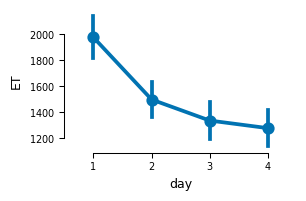

In [6]:
subjs_correct = utils.remove_error_trials(subjs)
subjs_grouped = subjs_correct.groupby(['SubNum' , 'day']).agg({'ET': 'median'}).reset_index()
sns.pointplot(data=subjs_grouped, x='day', y='ET', errorbar = 'se')
sns.despine(trim=True)

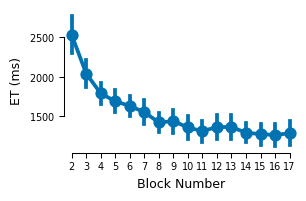

In [7]:
subjs_correct = utils.remove_error_trials(subjs)
subjs_grouped = subjs_correct.groupby(['SubNum' , 'BN']).agg({'ET': 'median'}).reset_index()
sns.pointplot(data=subjs_grouped, x='BN', y='ET', errorbar = 'se')
plt.xlabel('Block Number')
plt.ylabel('ET (ms)')
sns.despine(trim=True)
# plt.savefig(path_figs + 'ET_over_blocks.pdf', dpi=300, bbox_inches='tight')

In [27]:
# calculate distance of forces based on their trial distance for each subject
distances = []

forces_wide_correct = forces_wide[forces_wide['points'] != -1]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    # build 2D array of force_vectors 
    X = np.vstack(subdata['force_vector'].to_numpy())
    Y = subdata['ET'].to_numpy()
    trials = subdata['N'].to_numpy()
    blocks = subdata['BN'].to_numpy()
    n = len(subdata)

    #Upper triangular indices for distance calculation
    i, j = np.triu_indices(n, k=1)

    # Calculate pairwise distances
    force_dist = np.linalg.norm(X[i] - X[j], axis=1)
    trial_dist = np.abs(trials[i] - trials[j])
    et_dist = Y[i] - Y[j]
    block_dist = np.abs(blocks[i] - blocks[j])
    # speed_dist = -1 * (1/Y[i] - 1/Y[j])

    distances.append(pd.DataFrame({
        'SubNum': subind,
        'Trial1': trials[i],
        'Trial2': trials[j],
        'Force_Distance': force_dist,
        'Trial_Distance': trial_dist,
        'ET_Distance': et_dist,
        'Block_Distance': block_dist,
        'abs_ET_Distance': np.abs(et_dist),
        'first_trial_ET': Y[i],
        'second_trial_ET': Y[j]
        # 'Speed_Distance': speed_dist
    }))

# Concatenate all distances into a single DataFrame
distances_df = pd.concat(distances, ignore_index=True)


  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:11<00:00,  1.01s/it]


In [38]:
grouped_distances = (
    distances_df
    .groupby("SubNum")
    .agg(
        q25=("Force_Distance", lambda x: np.percentile(x, 25)),
        q50=("Force_Distance", lambda x: np.percentile(x, 50)),  # same as median
        q75=("Force_Distance", lambda x: np.percentile(x, 75))
    )
    .reset_index()
)

# add percentile columns to distances_df
distances_df = distances_df.merge(grouped_distances, on="SubNum", how="left")

local_range_distances = distances_df[distances_df['Trial_Distance'] <= 30].copy()

# #exclude first 80 trials 
# local_range_distances = local_range_distances[(local_range_distances['Trial1'] > 80) & (local_range_distances['Trial2'] > 80)].copy()

local_range_distances['is_close_force'] = local_range_distances.apply(
    lambda row: 0 if row['Force_Distance'] <= row['q25'] else (2 if row['Force_Distance'] >= row['q75'] else 1), axis=1
)

local_range_distances['count'] = 1

local_range_distances = local_range_distances[np.abs(local_range_distances['ET_Distance']) < 2000]

<Axes: xlabel='ET_Distance', ylabel='Count'>

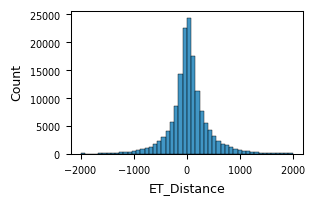

In [42]:
sns.histplot(local_range_distances, x = 'ET_Distance', bins = 50)

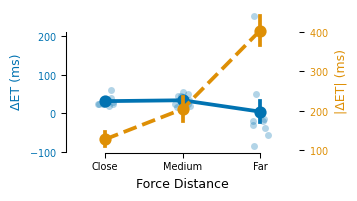

In [64]:
distances_grouped = local_range_distances.groupby(['SubNum', 'is_close_force']).agg({
    'ET_Distance': 'median',
    'abs_ET_Distance': 'median',
    'count': 'sum'
}).reset_index()

fig, ax1 = plt.subplots()

# Plot ET_Distance on the first y-axis
sns.pointplot(data=distances_grouped, y='ET_Distance', errorbar='se', x='is_close_force', ax=ax1, color=sns.color_palette("colorblind")[0])
sns.stripplot(data=distances_grouped, y='ET_Distance', x='is_close_force', color=sns.color_palette("colorblind")[0], alpha=0.3, jitter=0.1, ax=ax1)

ax1.set_xlabel('Force Distance')
ax1.set_ylabel('ΔET (ms)', color=sns.color_palette("colorblind")[0])
ax1.tick_params(axis='y', labelcolor=sns.color_palette("colorblind")[0])

# Create second y-axis for abs_ET_Distance
ax2 = ax1.twinx()
sns.pointplot(data=distances_grouped, y='abs_ET_Distance', errorbar='se', x='is_close_force', ax=ax2, color=sns.color_palette("colorblind")[1], linestyles='--')
# sns.stripplot(data=distances_grouped, y='abs_ET_Distance', x='is_close_force', color=sns.color_palette("colorblind")[1], alpha=0.3, jitter=0.1, ax=ax2, marker='s')

ax2.set_ylabel('|ΔET| (ms)', color=sns.color_palette("colorblind")[1])
ax2.tick_params(axis='y', labelcolor=sns.color_palette("colorblind")[1])

xticks_labels = ['Close', 'Medium', 'Far']
ax1.set_xticks(ticks=[0, 1, 2])
ax1.set_xticklabels(labels=xticks_labels)

sns.despine(trim=True)
plt.savefig(path_figs + 'local_range_et_distance_vs_force_distance_dual_axis.pdf', bbox_inches='tight', dpi=300)

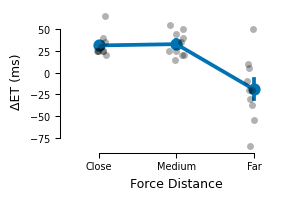

In [9]:
#exclude first subject
distances_grouped = distances_grouped[distances_grouped['SubNum'] != 1]
sns.pointplot(data=distances_grouped, y='ET_Distance', errorbar = 'se', x = 'is_close_force')
sns.stripplot(data = distances_grouped, y = 'ET_Distance', x = 'is_close_force', color = 'black', alpha = 0.3, jitter = 0.1)

xticks_labels = ['Close', 'Medium', 'Far']
plt.xticks(ticks=[0, 1, 2], labels=xticks_labels)
plt.xlabel('Force Distance')
plt.ylabel('ΔET (ms)')

sns.despine(trim=True)

plt.savefig(path_figs+ 'local_range_et_distance_vs_force_distance_exclude_sub1.pdf', bbox_inches='tight', dpi=300)


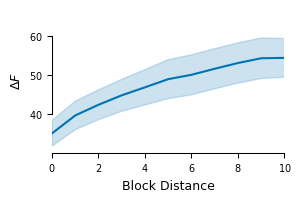

In [124]:
# plt.figure(figsize=(20, 6))

grouped_distances = distances_df.groupby(['SubNum', 'Block_Distance']).agg({'Force_Distance': 'median'}).reset_index()

sns.lineplot(data=grouped_distances, x='Block_Distance', y='Force_Distance', errorbar = 'se')

# plt.title('Force Distance vs Block Distance')
plt.xlabel('Block Distance')
plt.ylabel(r'$\Delta F$')

plt.xlim(0, 10)
sns.despine(trim=True)
plt.savefig(path_figs + 'force_distance_vs_block_distance.pdf', bbox_inches='tight', dpi=300)


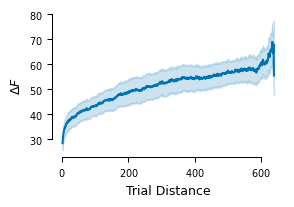

In [19]:
# plt.figure(figsize=(20, 6))

grouped_distances = distances_df.groupby(['SubNum', 'Trial_Distance']).agg({'Force_Distance': 'median'}).reset_index()

sns.lineplot(data=grouped_distances, x='Trial_Distance', y='Force_Distance', errorbar = 'se')

# plt.title('Force Distance vs Trial Distance')
plt.xlabel('Trial Distance')
plt.ylabel(r'$\Delta F$')

sns.despine(trim=True)
plt.savefig(path_figs + 'force_distance_vs_trial_distance.pdf', bbox_inches='tight', dpi=300)


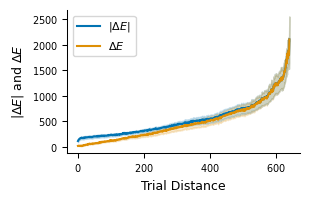

In [6]:
# plt.figure(figsize=(20, 6))

grouped_distances = distances_df[distances_df['abs_ET_Distance'] < 4000].groupby(['SubNum', 'Trial_Distance']).agg({'abs_ET_Distance': 'median',
                                                                                                                    'ET_Distance': 'median'}).reset_index()

sns.lineplot(data=grouped_distances, x='Trial_Distance', y='abs_ET_Distance', errorbar = 'se', label = r'$|\Delta E|$')
sns.lineplot(data=grouped_distances, x='Trial_Distance', y='ET_Distance', errorbar = 'se', label = r'$\Delta E$')

# plt.title('ET Distance vs Trial Distance')
plt.xlabel('Trial Distance')
plt.ylabel(r'$|\Delta E|$ and $\Delta E$')
plt.legend()

sns.despine()
plt.savefig(path_figs + 'absolute_and_signed_et_distance_vs_trial_distance.pdf', bbox_inches='tight', dpi=300)


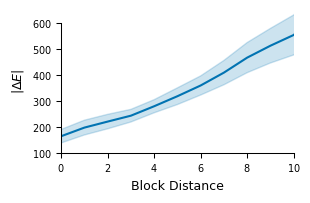

In [31]:
# plt.figure(figsize=(20, 6))

grouped_distances = distances_df[distances_df['abs_ET_Distance'] < 4000].groupby(['SubNum', 'Block_Distance']).agg({'abs_ET_Distance': 'median',
                                                                                                                    'ET_Distance': 'median'}).reset_index()

sns.lineplot(data=grouped_distances, x='Block_Distance', y='abs_ET_Distance', errorbar = 'se', label = r'$|\Delta E|$')
# sns.lineplot(data=grouped_distances, x='Block_Distance', y='ET_Distance', errorbar = 'se', label = r'$\Delta E$')

# plt.title('ET Distance vs Block Distance')
plt.xlabel('Block Distance')
# plt.ylabel(r'$|\Delta E|$ and $\Delta E$')
plt.ylabel(r'$|\Delta E|$')
plt.legend()
plt.legend().set_visible(False)
plt.xlim(0, 10)
plt.ylim(100, 650)


sns.despine(trim=True)
plt.savefig(path_figs + 'absolute_and_signed_et_distance_vs_block_distance.pdf', bbox_inches='tight', dpi=300)


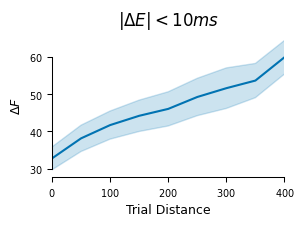

In [22]:
# plt.figure(figsize=(20, 6))
et_diff_cutoff = 10
trial_distances_bin_size = 50
matched_trials = distances_df[(distances_df['ET_Distance'] < et_diff_cutoff)
                              & (distances_df['ET_Distance'] > -et_diff_cutoff)].copy()
matched_trials['trial_distance_bin'] = (matched_trials['Trial_Distance'] // trial_distances_bin_size) * trial_distances_bin_size
matched_trials['count'] = 1
grouped_distances = matched_trials.groupby(['SubNum', 'trial_distance_bin']).agg({'Force_Distance': 'median',
                                                                              'count': 'sum'}).reset_index()

sns.lineplot(data=grouped_distances, x='trial_distance_bin', y='Force_Distance', errorbar = 'se')

plt.title(r'|$ \Delta E | < ' + str(et_diff_cutoff) + ' ms$')
plt.xlabel('Trial Distance')
plt.ylabel(r'$\Delta F$')

plt.xlim(0, 400)

sns.despine(trim=True)

plt.savefig(path_figs + 'matched_force_distance_vs_trial_distance.pdf', bbox_inches='tight', dpi=300)


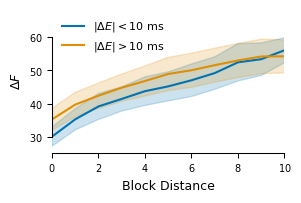

In [16]:
blocks_to_consider = list(range(1, 11))
et_diff_cutoff = 10
matched_trials = distances_df[(distances_df['ET_Distance'] < et_diff_cutoff)
                              & (distances_df['ET_Distance'] > -et_diff_cutoff)].copy()
# matched_trials['trial_distance_bin'] = (matched_trials['Trial_Distance'] // trial_distances_bin_size) * trial_distances_bin_size
matched_trials['count'] = 1
grouped_distances = matched_trials.groupby(['SubNum', 'Block_Distance']).agg({'Force_Distance': 'median',
                                                                              'count': 'sum'}).reset_index()

grouped_distances_less = grouped_distances[grouped_distances['Block_Distance'].isin(blocks_to_consider)].copy()

sns.lineplot(data=grouped_distances, x='Block_Distance', y='Force_Distance', errorbar = 'se', label = r'$|\Delta E| < $' + str(et_diff_cutoff) + ' ms')

# plt.title(r'|$ \Delta E | < ' + str(et_diff_cutoff) + ' ms$')

et_diff_cutoff = 10
matched_trials = distances_df[(distances_df['ET_Distance'] > et_diff_cutoff)
                              | (distances_df['ET_Distance'] < -et_diff_cutoff)].copy()
# matched_trials['trial_distance_bin'] = (matched_trials['Trial_Distance'] // trial_distances_bin_size) * trial_distances_bin_size
matched_trials['count'] = 1
grouped_distances = matched_trials.groupby(['SubNum', 'Block_Distance']).agg({'Force_Distance': 'median',
                                                                              'count': 'sum'}).reset_index()

grouped_distances_greater = grouped_distances[grouped_distances['Block_Distance'].isin(blocks_to_consider)].copy()

sns.lineplot(data=grouped_distances, x='Block_Distance', y='Force_Distance', errorbar = 'se', label = r'$|\Delta E| > $' + str(et_diff_cutoff) + ' ms')

# plt.title(r'|$ \Delta E | < ' + str(et_diff_cutoff) + ' ms$')
plt.xlabel('Block Distance')
plt.ylabel(r'$\Delta F$')

plt.xlim(0, 10)

plt.legend(frameon=False)
sns.despine(trim=True)

plt.savefig(path_figs + 'matched_and_unmatched_force_distance_vs_trial_distance.pdf', bbox_inches='tight', dpi=300)

# stats.ttest_rel(grouped_distances_less['Force_Distance'], grouped_distances_greater['Force_Distance'])



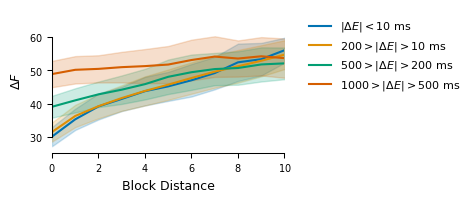

In [90]:
blocks_to_consider = list(range(1, 11))
et_diff_cutoff = 10
matched_trials = distances_df[(distances_df['ET_Distance'] < et_diff_cutoff)
                              & (distances_df['ET_Distance'] > -et_diff_cutoff)].copy()
# matched_trials['trial_distance_bin'] = (matched_trials['Trial_Distance'] // trial_distances_bin_size) * trial_distances_bin_size
matched_trials['count'] = 1
grouped_distances = matched_trials.groupby(['SubNum', 'Block_Distance']).agg({'Force_Distance': 'median',
                                                                              'count': 'sum'}).reset_index()



sns.lineplot(data=grouped_distances, x='Block_Distance', y='Force_Distance', errorbar = 'se', label = r'$|\Delta E| < $' + str(et_diff_cutoff) + ' ms')

# plt.title(r'|$ \Delta E | < ' + str(et_diff_cutoff) + ' ms$')

et_diff_cutoff = 10
et_diff_sup = 200

# matched_trials = distances_df[(distances_df['ET_Distance'] > et_diff_cutoff) | (distances_df['ET_Distance'] < -et_diff_cutoff)].copy()
matched_trials = distances_df[(np.abs(distances_df['ET_Distance']) > et_diff_cutoff) & (np.abs(distances_df['ET_Distance']) < et_diff_sup)].copy()
# matched_trials = distances_df[(np.abs(distances_df['ET_Distance']) > et_diff_cutoff) & np.abs(distances_df['ET_Distance']) < et_diff_sup].copy()
# matched_trials['trial_distance_bin'] = (matched_trials['Trial_Distance'] // trial_distances_bin_size) * trial_distances_bin_size
matched_trials['count'] = 1
grouped_distances = matched_trials.groupby(['SubNum', 'Block_Distance']).agg({'Force_Distance': 'median',
                                                                              'count': 'sum'}).reset_index()



sns.lineplot(data=grouped_distances, x='Block_Distance', y='Force_Distance', errorbar = 'se', label = str(et_diff_sup) + r'$> |\Delta E| > $' + str(et_diff_cutoff) + ' ms')


et_diff_cutoff = 200
et_diff_sup = 500

# matched_trials = distances_df[(distances_df['ET_Distance'] > et_diff_cutoff) | (distances_df['ET_Distance'] < -et_diff_cutoff)].copy()
matched_trials = distances_df[(np.abs(distances_df['ET_Distance']) > et_diff_cutoff) & (np.abs(distances_df['ET_Distance']) < et_diff_sup)].copy()
# matched_trials = distances_df[(np.abs(distances_df['ET_Distance']) > et_diff_cutoff) & np.abs(distances_df['ET_Distance']) < et_diff_sup].copy()
# matched_trials['trial_distance_bin'] = (matched_trials['Trial_Distance'] // trial_distances_bin_size) * trial_distances_bin_size
matched_trials['count'] = 1
grouped_distances = matched_trials.groupby(['SubNum', 'Block_Distance']).agg({'Force_Distance': 'median',
                                                                              'count': 'sum'}).reset_index()



sns.lineplot(data=grouped_distances, x='Block_Distance', y='Force_Distance', errorbar = 'se', label = str(et_diff_sup) + r'$> |\Delta E| > $' + str(et_diff_cutoff) + ' ms')



et_diff_cutoff = 500
et_diff_sup = 1000

matched_trials = distances_df[(np.abs(distances_df['ET_Distance']) > et_diff_cutoff) & (np.abs(distances_df['ET_Distance']) < et_diff_sup)].copy()
# matched_trials['trial_distance_bin'] = (matched_trials['Trial_Distance'] // trial_distances_bin_size) * trial_distances_bin_size
matched_trials['count'] = 1
grouped_distances = matched_trials.groupby(['SubNum', 'Block_Distance']).agg({'Force_Distance': 'median',
                                                                              'count': 'sum'}).reset_index()



sns.lineplot(data=grouped_distances, x='Block_Distance', y='Force_Distance', errorbar = 'se', label = str(et_diff_sup) + r'$> |\Delta E| > $' + str(et_diff_cutoff) + ' ms')

# plt.title(r'|$ \Delta E | < ' + str(et_diff_cutoff) + ' ms$')
plt.xlabel('Block Distance')
plt.ylabel(r'$\Delta F$')

plt.xlim(0, 10)

plt.legend(frameon=False, bbox_to_anchor=(1.8, 1), loc='upper right')
sns.despine(trim=True)

# plt.savefig(path_figs + 'matched_and_unmatched_force_distance_vs_trial_distance.pdf', bbox_inches='tight', dpi=300)

# stats.ttest_rel(grouped_distances_less['Force_Distance'], grouped_distances_greater['Force_Distance'])



<Axes: xlabel='et_bin_first', ylabel='count'>

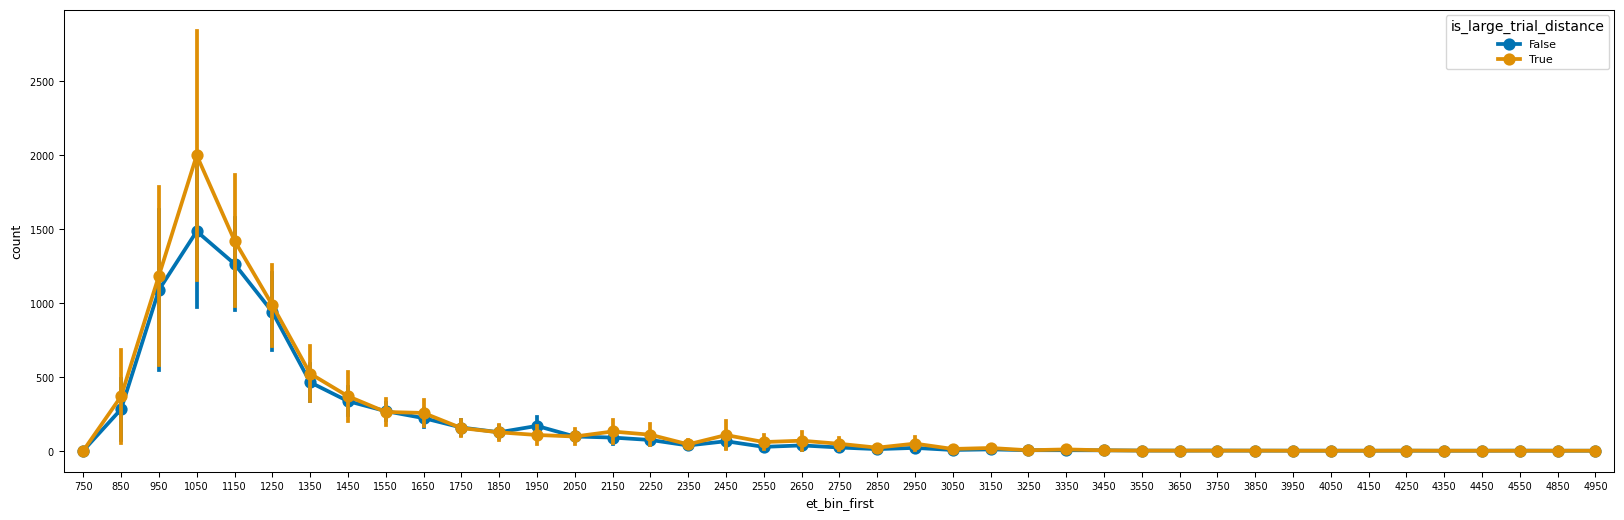

In [108]:
plt.figure(figsize=(20, 6))
et_bin_size = 100
stratifid_trials = distances_df.copy()
stratifid_trials['et_bin_first'] = (stratifid_trials['first_trial_ET'] // et_bin_size) * et_bin_size + et_bin_size // 2
stratifid_trials['et_bin_second'] = (stratifid_trials['second_trial_ET'] // et_bin_size) * et_bin_size + et_bin_size // 2

stratifid_trials = stratifid_trials[(stratifid_trials['et_bin_first'] == stratifid_trials['et_bin_second'])]

# stratifid_trials['is_large_trial_distance'] = stratifid_trials['Trial_Distance'] > 640//2
stratifid_trials['is_large_trial_distance'] = stratifid_trials['Trial_Distance'] > 100
stratifid_trials['count'] = 1

grouped_distances = stratifid_trials.groupby(['SubNum', 'et_bin_first', 'is_large_trial_distance']).agg({'Force_Distance': 'median',
                                                                              'count': 'sum'}).reset_index()

# insert missing values for each subject
all_subjects = stratifid_trials['SubNum'].unique()
all_et_bins = stratifid_trials['et_bin_first'].unique()
all_conditions = [True, False]
for subj in all_subjects:
    for et_bin in all_et_bins:
        for condition in all_conditions:
            if not ((grouped_distances['SubNum'] == subj) & 
                    (grouped_distances['et_bin_first'] == et_bin) & 
                    (grouped_distances['is_large_trial_distance'] == condition)).any():
                grouped_distances = pd.concat([grouped_distances, pd.DataFrame({
                    'SubNum': [subj],
                    'et_bin_first': [et_bin],
                    'is_large_trial_distance': [condition],
                    'Force_Distance': [np.nan],
                    'count': [0]
                })], ignore_index=True)

sns.pointplot(data=grouped_distances, x='et_bin_first', y='count', hue='is_large_trial_distance', errorbar = 'se')



<Axes: xlabel='et_bin_first', ylabel='count'>

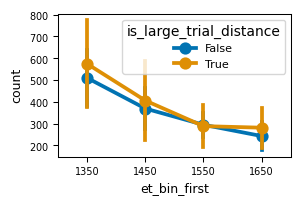

In [106]:
# plt.figure(figsize=(20, 6))
et_bin_size = 100
stratifid_trials = distances_df.copy()
stratifid_trials['et_bin_first'] = (stratifid_trials['first_trial_ET'] // et_bin_size) * et_bin_size + et_bin_size // 2
stratifid_trials['et_bin_second'] = (stratifid_trials['second_trial_ET'] // et_bin_size) * et_bin_size + et_bin_size // 2

stratifid_trials = stratifid_trials[(stratifid_trials['et_bin_first'] == stratifid_trials['et_bin_second'])]
stratifid_trials = stratifid_trials[(stratifid_trials['et_bin_first'] > 1300) & (stratifid_trials['et_bin_first'] < 1700) ]

# stratifid_trials['is_large_trial_distance'] = stratifid_trials['Trial_Distance'] > 640//2
stratifid_trials['is_large_trial_distance'] = stratifid_trials['Trial_Distance'] > 100

stratifid_trials['count'] = 1

grouped_distances = stratifid_trials.groupby(['SubNum', 'et_bin_first', 'is_large_trial_distance']).agg({'Force_Distance': 'median',
                                                                              'count': 'sum'}).reset_index()

# insert missing values for each subject
all_subjects = stratifid_trials['SubNum'].unique()
all_et_bins = stratifid_trials['et_bin_first'].unique()
all_conditions = [True, False]
for subj in all_subjects:
    for et_bin in all_et_bins:
        for condition in all_conditions:
            if not ((grouped_distances['SubNum'] == subj) & 
                    (grouped_distances['et_bin_first'] == et_bin) & 
                    (grouped_distances['is_large_trial_distance'] == condition)).any():
                grouped_distances = pd.concat([grouped_distances, pd.DataFrame({
                    'SubNum': [subj],
                    'et_bin_first': [et_bin],
                    'is_large_trial_distance': [condition],
                    'Force_Distance': [np.nan],
                    'count': [0]
                })], ignore_index=True)

sns.pointplot(data=grouped_distances, x='et_bin_first', y='count', hue='is_large_trial_distance', errorbar = 'se')

# matched_trials = distances_df[(distances_df['ET_Distance'] < et_diff_cutoff)
#                               & (distances_df['ET_Distance'] > -et_diff_cutoff)].copy()
# matched_trials['trial_distance_bin'] = (matched_trials['Trial_Distance'] // trial_distances_bin_size) * trial_distances_bin_size
# matched_trials['count'] = 1
# grouped_distances = matched_trials.groupby(['SubNum', 'trial_distance_bin']).agg({'Force_Distance': 'median',
#                                                                               'count': 'sum'}).reset_index()

# sns.lineplot(data=grouped_distances, x='trial_distance_bin', y='Force_Distance', errorbar = 'se')

# plt.title(r'|$ \Delta E | < ' + str(et_diff_cutoff) + ' ms$')
# plt.xlabel('Trial Distance')
# plt.ylabel(r'$\Delta F$')

# plt.xlim(0, 400)

# sns.despine(trim=True)

# plt.savefig(path_figs + 'matched_force_distance_vs_trial_distance.pdf', bbox_inches='tight', dpi=300)


In [136]:
grouped_distances

,SubNum,et_bin_first,is_large_trial_distance,Force_Distance,count
0,1,1350,False,42.814344,668
1,1,1350,True,64.755065,928
2,1,1450,False,26.022992,496
3,1,1450,True,58.073353,407
4,1,1550,False,26.329100,513
...,...,...,...,...,...
75,11,1450,True,69.814210,1966
76,11,1550,False,47.028467,409
77,11,1550,True,71.475152,1076
78,11,1650,False,48.801565,266


/var/folders/wg/16zn32014z5grhdv06dk49f00000gn/T/ipykernel_38252/396157931.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(xtick_labels, rotation=45, ha='right')


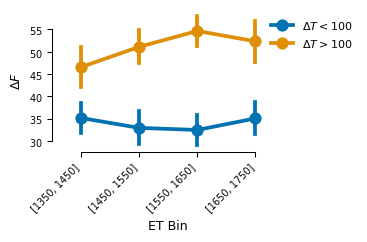

In [135]:

et_bin_size = 100
stratifid_trials = distances_df.copy()
stratifid_trials['et_bin_first'] = (stratifid_trials['first_trial_ET'] // et_bin_size) * et_bin_size + et_bin_size // 2
stratifid_trials['et_bin_second'] = (stratifid_trials['second_trial_ET'] // et_bin_size) * et_bin_size + et_bin_size // 2

stratifid_trials = stratifid_trials[(stratifid_trials['et_bin_first'] == stratifid_trials['et_bin_second'])]
stratifid_trials = stratifid_trials[(stratifid_trials['et_bin_first'] > 1300) & (stratifid_trials['et_bin_first'] < 1700) ]

# stratifid_trials['is_large_trial_distance'] = stratifid_trials['Trial_Distance'] > 640//2
stratifid_trials['is_large_trial_distance'] = stratifid_trials['Trial_Distance'] > 100

stratifid_trials['count'] = 1

grouped_distances = stratifid_trials.groupby(['SubNum', 'et_bin_first', 'is_large_trial_distance']).agg({'Force_Distance': 'median',
                                                                              'count': 'sum'}).reset_index()

# insert missing values for each subject
all_subjects = stratifid_trials['SubNum'].unique()
all_et_bins = stratifid_trials['et_bin_first'].unique()
all_conditions = [True, False]
for subj in all_subjects:
    for et_bin in all_et_bins:
        for condition in all_conditions:
            if not ((grouped_distances['SubNum'] == subj) & 
                    (grouped_distances['et_bin_first'] == et_bin) & 
                    (grouped_distances['is_large_trial_distance'] == condition)).any():
                grouped_distances = pd.concat([grouped_distances, pd.DataFrame({
                    'SubNum': [subj],
                    'et_bin_first': [et_bin],
                    'is_large_trial_distance': [condition],
                    'Force_Distance': [np.nan],
                    'count': [0]
                })], ignore_index=True)

hue_order = [False, True]
sns.pointplot(data=grouped_distances, x='et_bin_first', y='Force_Distance', hue='is_large_trial_distance', errorbar = 'se', hue_order=hue_order)

# plt.title(r'|$ \Delta E | < ' + str(et_diff_cutoff) + ' ms$')
plt.xlabel('ET Bin')
plt.ylabel(r'$\Delta F$')




xtick_labels = [f'[{int(tick) * et_bin_size + 1350}, {int(tick) * et_bin_size + 1350 + et_bin_size}]' for tick in plt.gca().get_xticks()]
plt.gca().set_xticklabels(xtick_labels, rotation=45, ha='right')

# legend labels
handles, labels = plt.gca().get_legend_handles_labels()
label_mapping = { 'False': r'$\Delta T < 100$', 'True': r'$\Delta T > 100$' }
new_labels = [label_mapping[label] for label in labels]
plt.gca().legend(handles, new_labels, title='', loc='upper left', frameon=False, bbox_to_anchor=(0.9, 1))




sns.despine(trim=True)

plt.savefig(path_figs + 'stratified_force_distance_vs_et_bins.pdf', bbox_inches='tight', dpi=300)


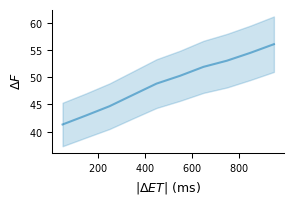

In [17]:
# plt.figure(figsize=(20, 6))

# grouped_distances = distances_df.groupby(['SubNum', 'Trial_Distance']).agg({'Force_Distance': 'median'}).reset_index()

# sns.lineplot(data=grouped_distances, x='Trial_Distance', y='Force_Distance', errorbar = 'se')
ET_diff_bin_size = 100
distances_df = distances_df.copy()
distances_df['count'] = 1
distances_df['ET_Distance'] = np.abs(distances_df['ET_Distance'])
# consider only distances within -1000 to 1000 ms
distances_df = distances_df[distances_df['ET_Distance'] < 1000]
distances_df['ET_diff_bin'] = distances_df['ET_Distance'] // ET_diff_bin_size * ET_diff_bin_size + ET_diff_bin_size // 2

grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin']).agg({'Force_Distance': 'median',
                                                                                'count': 'sum'}).reset_index()
sns.lineplot(data = grouped_distances, x = 'ET_diff_bin', y = 'Force_Distance', errorbar = 'se', alpha = 0.5)


# plt.title('Force Distance vs ET Distance')
plt.xlabel(r'$|\Delta ET|$ (ms)')
plt.ylabel(r'$\Delta F$')
# plt.xlim(0, 1000)

sns.despine()
# plt.savefig(path_figs + 'force_distance_vs_absolute_et_distance.pdf', bbox_inches='tight', dpi=300)



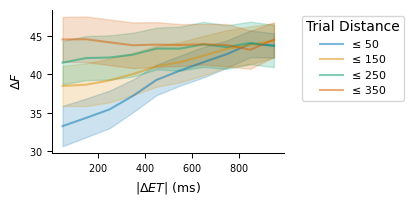

In [45]:
# plt.figure(figsize=(20, 6))

ET_diff_bin_size = 100
trial_distance_bin = 100
distances_df = distances_df.copy()
distances_df['count'] = 1
distances_df['ET_Distance'] = np.abs(distances_df['ET_Distance'])
# consider only distances within -1000 to 1000 ms
distances_df = distances_df[distances_df['ET_Distance'] < 1000]
distances_df = distances_df[distances_df['Force_Distance'] < 60]
distances_df = distances_df[distances_df['Trial_Distance'] < 400]
distances_df['ET_diff_bin'] = distances_df['ET_Distance'] // ET_diff_bin_size * ET_diff_bin_size + ET_diff_bin_size // 2

distances_df['trial_distance_bin'] = distances_df['Trial_Distance'] // trial_distance_bin * trial_distance_bin + trial_distance_bin // 2


grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'trial_distance_bin']).agg({'Force_Distance': 'median',
                                                                                'count': 'sum'}).reset_index()

sns.lineplot(data = grouped_distances, x = 'ET_diff_bin', y = 'Force_Distance', errorbar = 'se', alpha = 0.5, hue = 'trial_distance_bin',
             palette= 'colorblind')

# sns.lmplot(distances_df, x='ET_Distance', y='Force_Distance', ci=None, scatter_kws={'alpha':0.002, 's':5, 'color': 'black'},
#            hue = 'trial_distance_bin')


# plt.title('Force Distance vs ET Distance')
plt.xlabel(r'$|\Delta ET|$ (ms)')
plt.ylabel(r'$\Delta F$')
handles, labels = plt.gca().get_legend_handles_labels()
formatted_labels = [
    f'≤ {label}' if label != 'Trial Distance' else label
    for label in labels
]
plt.legend(handles, formatted_labels, title='Trial Distance',
           bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.legend(title='Trial Distance', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xlim(0, 1000)

sns.despine()
plt.savefig(path_figs + 'force_distance_vs_ET_distance_by_trial_distance.pdf', bbox_inches='tight', dpi=300)



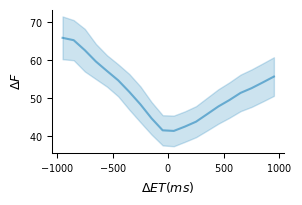

In [26]:
# plt.figure(figsize=(20, 6))

# grouped_distances = distances_df.groupby(['SubNum', 'Trial_Distance']).agg({'Force_Distance': 'median'}).reset_index()

# sns.lineplot(data=grouped_distances, x='Trial_Distance', y='Force_Distance', errorbar = 'se')
ET_diff_bin_size = 100
distances_df = distances_df.copy()
distances_df['count'] = 1
distances_df = distances_df[(distances_df['ET_Distance'] < 1000) & (distances_df['ET_Distance'] > -1000)]
distances_df['ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) * ET_diff_bin_size + ET_diff_bin_size // 2
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin']).agg({'Force_Distance': 'median',
                                                                                'count': 'sum'}).reset_index()
sns.lineplot(data = grouped_distances, x = 'ET_diff_bin', y = 'Force_Distance', errorbar = 'se', alpha = 0.5)

# plt.title('Force Distance vs ET Distance')
plt.xlabel(r'$\Delta ET (ms)$')
plt.ylabel(r'$\Delta F$')

sns.despine()
plt.savefig(path_figs + 'force_distance_vs_et_distance.pdf', bbox_inches='tight', dpi=300)



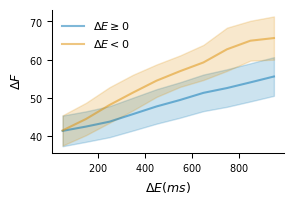

In [28]:
# plt.figure(figsize=(20, 6))

# grouped_distances = distances_df.groupby(['SubNum', 'Trial_Distance']).agg({'Force_Distance': 'median'}).reset_index()

# sns.lineplot(data=grouped_distances, x='Trial_Distance', y='Force_Distance', errorbar = 'se')
ET_diff_bin_size = 100
distances_df_filtered = distances_df.copy()
distances_df_filtered['is_positive'] = distances_df_filtered['ET_Distance'] >= 0
distances_df_filtered['ET_Distance'] = np.abs(distances_df_filtered['ET_Distance'])
distances_df_filtered['count'] = 1
distances_df_filtered = distances_df_filtered[(distances_df_filtered['ET_Distance'] < 1000) & (distances_df_filtered['ET_Distance'] > -1000)]
distances_df_filtered['ET_diff_bin'] = (distances_df_filtered['ET_Distance'] // ET_diff_bin_size) * ET_diff_bin_size + ET_diff_bin_size // 2
grouped_distances = distances_df_filtered.groupby(['SubNum', 'ET_diff_bin', 'is_positive']).agg({'Force_Distance': 'median',
                                                                                'count': 'sum'}).reset_index()

hue_order = [True, False]  # True for ΔE >= 0, False for ΔE < 0
sns.lineplot(data = grouped_distances, x = 'ET_diff_bin', y = 'Force_Distance', errorbar = 'se', alpha = 0.5,
             hue = 'is_positive', hue_order=hue_order)

# plt.title('Force Distance vs ET Distance')
plt.xlabel(r'$\Delta E (ms)$')
plt.ylabel(r'$\Delta F$')

# Build legend with correct handle-label mapping
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {'True': r'$\Delta E \geq 0$', 'False': r'$\Delta E < 0$'}
ordered_labels = ['True', 'False']
ordered_handles = [handles[labels.index(l)] for l in ordered_labels]
plt.legend(ordered_handles, [label_map[l] for l in ordered_labels], frameon=False, title='')

sns.despine()
plt.savefig(path_figs + 'force_distance_vs_et_distance_signed.pdf', bbox_inches='tight', dpi=300)


TtestResult(statistic=-4.077574440446515, pvalue=0.0022229994114766876, df=10)

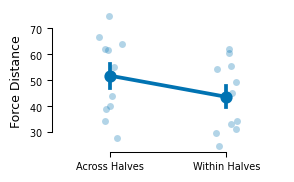

In [419]:
# seperate first half(trial number <= 640/2) and second half (trial number > 640/2)
distances_df['is_within'] = (distances_df['Trial2'] <= 640/2) | (distances_df['Trial1'] > 640/2)

grouped_distances = distances_df.groupby(['SubNum', 'is_within']).agg({'Force_Distance': 'median'}).reset_index()

sns.stripplot(data=grouped_distances, x='is_within', y='Force_Distance', alpha = 0.3, legend=False)
sns.pointplot(data=grouped_distances, x='is_within', y='Force_Distance', errorbar = 'se')
# plt.xlabel('Across Half vs Within Halves')
plt.xticks([0, 1], ['Across Halves', 'Within Halves'])
plt.xlabel(None)
plt.ylabel('Force Distance')
sns.despine(trim=True)
plt.savefig(path_figs + 'force_distance_across_halves.pdf', bbox_inches='tight', dpi=300)

stats.ttest_rel(grouped_distances[grouped_distances['is_within'] == True]['Force_Distance'], grouped_distances[grouped_distances['is_within'] == False]['Force_Distance'])






In [144]:
# calculate distance of forces based on their trial distance for each subject
distances = []

forces_wide_correct = forces_wide[forces_wide['points'] != -1]
forces_wide_correct = forces_wide_correct.sort_values(by = ['SubNum' , 'BN', 'TN'])

# filter out subnum 8
# forces_wide_correct = forces_wide_correct[forces_wide_correct['SubNum'] != 8]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            mean_block_et = block_data['ET'].mean()
            for i in range(len(block_data) - 1):
                trial1 = block_data.iloc[i]
                trial2 = block_data.iloc[i + 1]
                if trial2['N'] - trial1['N'] == 1:  # only consider consecutive trials
                    # Calculate force distance
                    force_dist = np.linalg.norm(trial2['force_vector'] - trial1['force_vector'])
                    # Calculate ETs
                    first_ET = trial1['ET']
                    second_ET = trial2['ET']
                    # Calculate zones
                    first_zone = trial1['zone']
                    second_zone = trial2['zone']

                    distances.append({
                        'SubNum': subind,
                        'Force_Distance': force_dist,
                        'first_ET': first_ET,
                        'second_ET': second_ET,
                        'block_ET_mean': mean_block_et,
                        'first_zone': first_zone,
                        'second_zone': second_zone,
                        'day': day
                    })

# Concatenate all distances into a single DataFrame
distances_df = pd.DataFrame(distances)

distances_df['count'] = 1


100%|██████████| 11/11 [00:04<00:00,  2.72it/s]


### ET based analysis

In [145]:
cut_off_percentile = 95
force_distance_cutoff = distances_df['Force_Distance'].quantile(cut_off_percentile / 100)
distances_df = distances_df[distances_df['Force_Distance'] <= force_distance_cutoff]

# exclude first day
distances_df = distances_df[distances_df['day'] != 1]

In [146]:
# distances_df = distances_df[(distances_df['first_ET'] < 1500) & (distances_df['second_ET'] < 1500)]
# distances_df = distances_df[(distances_df['first_ET'] < 3000) & (distances_df['second_ET'] < 3000)]

distances_df['first_mean_block_ET'] = distances_df['first_ET'] - distances_df['block_ET_mean']
distances_df['second_mean_block_ET'] = distances_df['second_ET'] - distances_df['block_ET_mean']

marginal_distances = distances_df.groupby(['SubNum', 'first_ET']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

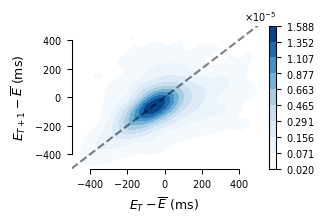

In [154]:
# Density plot 
distances_df = distances_df[(distances_df['first_mean_block_ET'] > -500) & (distances_df['first_mean_block_ET'] < 500)]
distances_df = distances_df[(distances_df['second_mean_block_ET'] > -500) & (distances_df['second_mean_block_ET'] < 500)]
sns.kdeplot(data = distances_df, x = 'first_mean_block_ET', y = 'second_mean_block_ET', fill = True, cmap = 'Blues', cbar = True)
# draw x = y line
plt.plot([-500, 500], [-500, 500], color = 'black', linestyle = '--', alpha = 0.5)
plt.xlim(-500, 500)
plt.ylim(-500, 500)
plt.xlabel(r'$E_T -\overline{E}$ (ms)')
plt.ylabel(r'$E_{T+1} -\overline{E}$ (ms)')
sns.despine(trim=True)

plt.savefig(path_figs + 'ET_density_plot.pdf', bbox_inches='tight', dpi=300)


In [117]:
def kernel_smoother(x, y, z, xi, yi, h = 0.1):
    """
    smooth scattered (x,y,z) onto grid (xi, yi) using Gaussian kernel smoother
    """

    # query points flattened
    xq = np.column_stack((xi.flatten(), yi.flatten()))
    x = np.column_stack((x, y))

    zout = np.zeros(len(xq))

    for j, q in enumerate(xq):
        # distances from query point to all data points
        d = np.linalg.norm(x - q, axis=1)
        # Gaussian kernel weights
        w = np.exp(-(d/h)**2 / 2)
        #normalized weighted average
        if np.sum(w) > 0:
            zout[j] = np.sum(w * z) / np.sum(w)
        else:
            zout[j] = np.nan
    return zout.reshape(xi.shape)


def kernel_smoother_1d(x, y, xi, h = 0.1):
    """
    smooth scattered (x,y) onto grid (xi) using Gaussian kernel smoother
    """
    xq = xi.flatten()
    zout = np.zeros(len(xq))

    for j, q in enumerate(xq):
        # distances from query point to all data points
        d = np.abs(x - q)
        # Gaussian kernel weights
        w = np.exp(-(d/h)**2 / 2)
        #normalized weighted average
        if np.sum(w) > 0:
            zout[j] = np.sum(w * y) / np.sum(w)
        else:
            zout[j] = np.nan
    return zout.reshape(xi.shape)

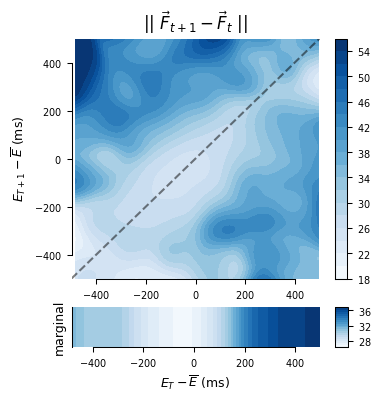

In [143]:
x = distances_df['first_mean_block_ET']
y = distances_df['second_mean_block_ET']
z = distances_df['Force_Distance']

# evaluate on a grid
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
xi, yi = np.meshgrid(xi, yi)

zi = kernel_smoother(x, y, z, xi, yi, h = 50)
fig, (ax1, ax2) = plt.subplots(2,1, figsize = (4,4), height_ratios=[6,1])
# m1 = ax1.contourf(xi, yi, zi, levels = 50, cmap = 'Blues')
m1 = ax1.contourf(xi, yi, zi, cmap = 'Blues', levels = 20)

fig.colorbar(m1, ax = ax1)
# draw x = y line
ax1.plot([-500, 500], [-500, 500], color = 'black', linestyle = '--', alpha = 0.5)
 
ax1.set_xlim(-500, 500)
ax1.set_ylim(-500, 500)
ax1.set_title(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')

x = distances_df['first_mean_block_ET']
z = distances_df['Force_Distance']
# evaluate on a grid
xi = np.linspace(x.min(), x.max(), 200)
yi = [0,2]
xi, yi = np.meshgrid(xi, yi)
zi = kernel_smoother_1d(x, z, xi, h = 50)
m2 = ax2.contourf(xi, yi, zi, cmap = 'Blues', levels = 20)
cbar2 = fig.colorbar(m2, ax = ax2, aspect = 3)
cbar2.locator = ticker.MaxNLocator(nbins=3)
ax2.set_yticks([])
ax2.set_xlabel(r'$E_T -\overline{E}$ (ms)')
ax2.set_ylabel('marginal')
ax1.set_ylabel(r'$E_{T+1} -\overline{E}$ (ms)')
sns.despine(trim=True)

plt.savefig(path_figs + 'force_distance_vs_ET.pdf', bbox_inches='tight', dpi=300)



### Zone based analysis 

In [127]:
grouped_distances = distances_df.groupby(['SubNum', 'first_zone', 'second_zone']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

grouped_distances = grouped_distances.groupby(['first_zone', 'second_zone']).agg({
    'Force_Distance': 'mean',
    'count': 'sum'
}).reset_index()

grouped_marginal_distances = distances_df.groupby(['SubNum', 'first_zone']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

grouped_marginal_distances = grouped_marginal_distances.groupby(['first_zone']).agg({
    'Force_Distance': 'mean',
    'count': 'sum'
}).reset_index()



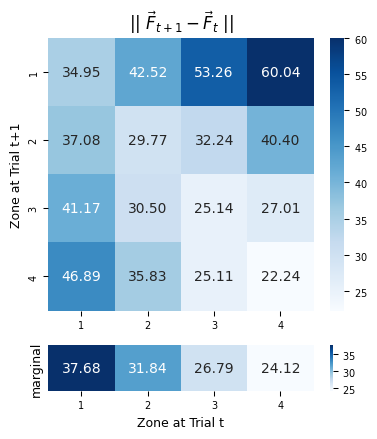

In [129]:
# Create a figure with 2 subplots arranged vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4.5), height_ratios=[6, 1])

# Plot the main heatmap on the top subplot
heatmap_data = grouped_distances.pivot(index='second_zone', columns='first_zone', values='Force_Distance')
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Blues", ax=ax1)
ax1.set_title(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
ax1.set_ylabel('Zone at Trial t+1')
ax1.set_xlabel('Zone at Trial t')
ax1.set_xlabel(None)


# Plot the marginal heatmap on the bottom subplot
marginal_heatmap_data = grouped_marginal_distances['temp'] = 1  # Dummy column for pivoting
marginal_heatmap_data = grouped_marginal_distances.pivot(index='temp', columns='first_zone', values='Force_Distance')
sns.heatmap(marginal_heatmap_data, annot=True, fmt=".2f", cmap="Blues", ax=ax2)
# ax2.set_title('Marginal')
ax2.set_ylabel('marginal')
ax2.set_yticks([])  # Hide y-axis ticks for the marginal heatmap
ax2.set_xlabel('Zone at Trial t')

plt.tight_layout()

plt.savefig(path_figs + 'force_distance_vs_zone.pdf', bbox_inches='tight', dpi=300)

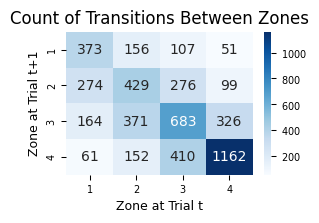

In [130]:
heatmap_data = grouped_distances.pivot(index='second_zone', columns='first_zone', values='count')
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Blues")
plt.title('Count of Transitions Between Zones')
plt.xlabel('Zone at Trial t')
plt.ylabel('Zone at Trial t+1')

plt.savefig(path_figs + 'count_transitions_between_zones.pdf', bbox_inches='tight', dpi=300)


In [207]:
def model_visualization(model):
    model_df = pd.DataFrame(model, index = ['1', '2', '3', '4'], columns = ['1', '2', '3', '4'])
    model_df.index.name = 'second_zone'
    model_df.columns.name = 'first_zone'
    sns.heatmap(model_df, annot=True, fmt=".2f", cmap="Blues")

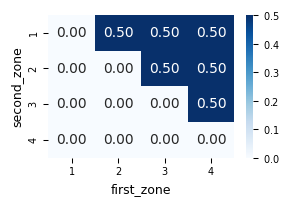

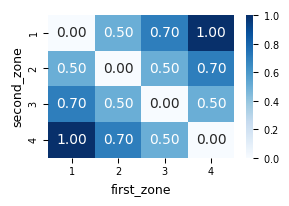

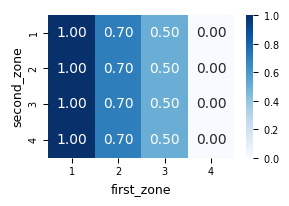

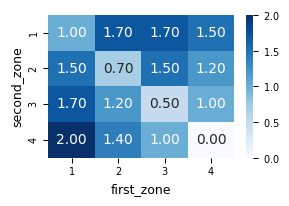

In [208]:
# first model: order
# second model: major diagonal
# third model: ET of trial t

first_model = np.ones((4,4)) * 0.5
first_model = np.triu(first_model, k = 1)



second_model = np.zeros((4,4))
level_values = [0, 0.5, 0.7, 1]
for k, value in enumerate(level_values):
    second_model += np.eye(4, k = k) * value
    second_model += np.eye(4, k = -k) * value

third_model = np.zeros((4,4))
level_values = [0, 0.5, 0.7, 1][::-1]
for k, value in enumerate(level_values):
    third_model[:, k] = value

final_model = first_model + second_model + third_model

for models in [first_model, second_model, third_model, final_model]:
    model_visualization(models)
    plt.show()

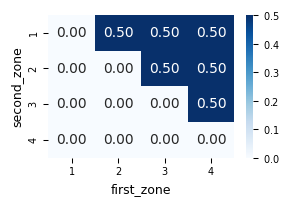

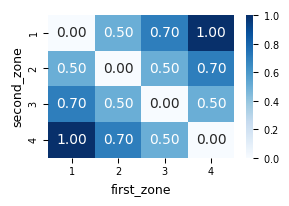

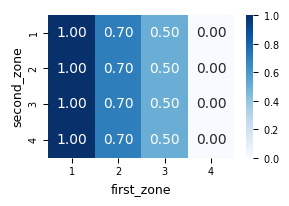

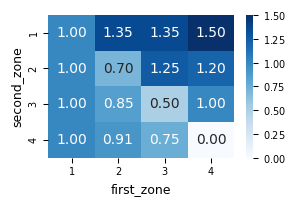

In [209]:
final_model = first_model + second_model + third_model - second_model * third_model

for models in [first_model, second_model, third_model, final_model]:
    model_visualization(models)
    plt.show()

In [131]:
# calculate distance of forces based on their trial distance for each subject
distances = []

# forces_wide_correct = forces_wide[forces_wide['points'] != -1]
forces_wide_correct = forces_wide

# filter out subnum 8
# forces_wide_correct = forces_wide_correct[forces_wide_correct['SubNum'] != 8]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            for i in range(len(block_data) - 1):
                trial1 = block_data.iloc[i]
                trial2 = block_data.iloc[i + 1]
                if trial2['N'] - trial1['N'] == 1:  # only consider consecutive trials
                    # Calculate force distance
                    force_dist = np.linalg.norm(trial2['force_vector'] - trial1['force_vector'])
                    # Calculate ETs
                    first_ET = trial1['ET']
                    second_ET = trial2['ET']
                    # Calculate zones
                    first_zone = trial1['zone']
                    second_zone = trial2['zone']

                    distances.append({
                        'SubNum': subind,
                        'Force_Distance': force_dist,
                        'first_ET': first_ET,
                        'second_ET': second_ET,
                        'first_zone': first_zone,
                        'second_zone': second_zone,
                        'day': day
                    })

# Concatenate all distances into a single DataFrame
distances_df = pd.DataFrame(distances)

distances_df['count'] = 1


  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:19<00:00,  1.77s/it]


In [132]:
grouped_distances = distances_df.groupby(['SubNum', 'first_zone', 'second_zone']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

grouped_distances = grouped_distances.groupby(['first_zone', 'second_zone']).agg({
    'Force_Distance': 'mean',
    'count': 'sum'
}).reset_index()

grouped_marginal_distances = distances_df.groupby(['SubNum', 'first_zone']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

grouped_marginal_distances = grouped_marginal_distances.groupby(['first_zone']).agg({
    'Force_Distance': 'mean',
    'count': 'sum'
}).reset_index()



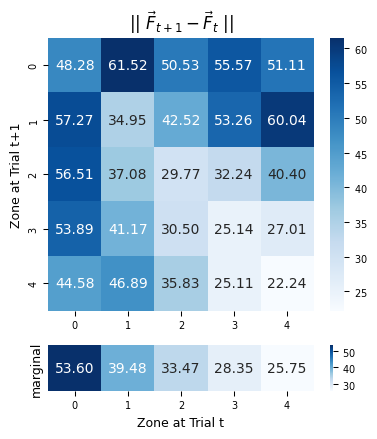

In [134]:
# Create a figure with 2 subplots arranged vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4.5), height_ratios=[6, 1])

# Plot the main heatmap on the top subplot
heatmap_data = grouped_distances.pivot(index='second_zone', columns='first_zone', values='Force_Distance')
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Blues", ax=ax1)
ax1.set_title(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
ax1.set_ylabel('Zone at Trial t+1')
ax1.set_xlabel('Zone at Trial t')
ax1.set_xlabel(None)


# Plot the marginal heatmap on the bottom subplot
marginal_heatmap_data = grouped_marginal_distances['temp'] = 1  # Dummy column for pivoting
marginal_heatmap_data = grouped_marginal_distances.pivot(index='temp', columns='first_zone', values='Force_Distance')
sns.heatmap(marginal_heatmap_data, annot=True, fmt=".2f", cmap="Blues", ax=ax2)
# ax2.set_title('Marginal')
ax2.set_ylabel('marginal')
ax2.set_yticks([])  # Hide y-axis ticks for the marginal heatmap
ax2.set_xlabel('Zone at Trial t')

plt.tight_layout()
plt.savefig(path_figs + 'force_distance_vs_zone_all_points.pdf', bbox_inches='tight', dpi=300)

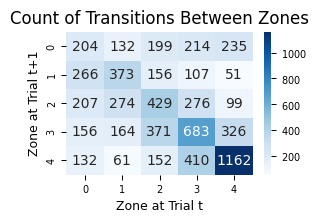

In [135]:
heatmap_data = grouped_distances.pivot(index='second_zone', columns='first_zone', values='count')
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Blues")
plt.title('Count of Transitions Between Zones')
plt.xlabel('Zone at Trial t')
plt.ylabel('Zone at Trial t+1')
plt.savefig(path_figs + 'count_transitions_between_zones_all_points.pdf', bbox_inches='tight', dpi=300)

### Breaking down into press time and peak force distances


In [136]:
# calculate distance of forces based on their trial distance for each subject
RT_offset = 0.1
distances = []
subjs_correct = utils.remove_error_trials(subjs)

subjs_correct = subjs_correct.sort_values(by = ['SubNum' , 'BN', 'TN'])

for subind, subdata in tqdm(subjs_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            for i in range(len(block_data) - 1):
                trial1 = block_data.iloc[i]
                trial2 = block_data.iloc[i + 1]
                if trial2['N'] - trial1['N'] == 1:  # only consider consecutive trials
                    # normalize press times
                    norm_press_times_1 = np.array([trial1[f'IPI{i}'] for i in range(1, seq_length)])
                    norm_press_times_2 = np.array([trial2[f'IPI{i}'] for i in range(1, seq_length)])

                    norm_press_times_1 = norm_press_times_1 / trial1['MT']
                    norm_press_times_2 = norm_press_times_2 / trial2['MT']

                    norm_press_times_1 = np.cumsum(norm_press_times_1) + RT_offset
                    norm_press_times_2 = np.cumsum(norm_press_times_2) + RT_offset
                    # Calculate force distance
                    force_dist = np.linalg.norm(norm_press_times_2 - norm_press_times_1)
                    # Calculate ETs
                    first_ET = trial1['ET']
                    second_ET = trial2['ET']
                    # Calculate zones
                    first_zone = trial1['zone']
                    second_zone = trial2['zone']

                    distances.append({
                        'SubNum': subind,
                        'Force_Distance': force_dist,
                        'first_ET': first_ET,
                        'second_ET': second_ET,
                        'first_zone': first_zone,
                        'second_zone': second_zone,
                        'day': day
                    })

# Concatenate all distances into a single DataFrame
distances_df = pd.DataFrame(distances)

distances_df['count'] = 1


                    


100%|██████████| 11/11 [00:02<00:00,  5.20it/s]


In [137]:
grouped_distances = distances_df.groupby(['SubNum', 'first_zone', 'second_zone']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

grouped_distances = grouped_distances.groupby(['first_zone', 'second_zone']).agg({
    'Force_Distance': 'mean',
    'count': 'sum'
}).reset_index()

grouped_marginal_distances = distances_df.groupby(['SubNum', 'first_zone']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

grouped_marginal_distances = grouped_marginal_distances.groupby(['first_zone']).agg({
    'Force_Distance': 'mean',
    'count': 'sum'
}).reset_index()



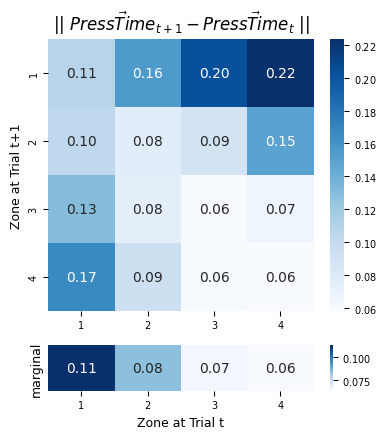

In [139]:
# Create a figure with 2 subplots arranged vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4.5), height_ratios=[6, 1])

# Plot the main heatmap on the top subplot
heatmap_data = grouped_distances.pivot(index='second_zone', columns='first_zone', values='Force_Distance')
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Blues", ax=ax1)
ax1.set_title(r'|| $\vec{Press Time}_{t+1} - \vec{Press Time}_{t}$ ||')
ax1.set_ylabel('Zone at Trial t+1')
ax1.set_xlabel('Zone at Trial t')
ax1.set_xlabel(None)


# Plot the marginal heatmap on the bottom subplot
marginal_heatmap_data = grouped_marginal_distances['temp'] = 1  # Dummy column for pivoting
marginal_heatmap_data = grouped_marginal_distances.pivot(index='temp', columns='first_zone', values='Force_Distance')
sns.heatmap(marginal_heatmap_data, annot=True, fmt=".2f", cmap="Blues", ax=ax2)
# ax2.set_title('Marginal')
ax2.set_ylabel('marginal')
ax2.set_yticks([])  # Hide y-axis ticks for the marginal heatmap
ax2.set_xlabel('Zone at Trial t')

plt.tight_layout()

plt.savefig(path_figs + 'press_time_distance_vs_zone_all_points.pdf', bbox_inches='tight', dpi=300)

Text(12.222242472222229, 0.5, 'Zone at Trial t+1')

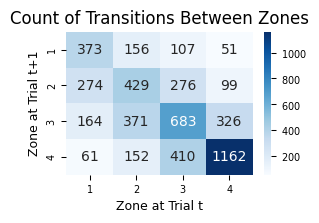

In [303]:
heatmap_data = grouped_distances.pivot(index='second_zone', columns='first_zone', values='count')
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Blues")
plt.title('Count of Transitions Between Zones')
plt.xlabel('Zone at Trial t')
plt.ylabel('Zone at Trial t+1')


In [140]:
# calculate distance of forces based on their trial distance for each subject
distances = []


peak_forces_correct = peak_forces[peak_forces['points'] != -1]

peak_forces_correct = peak_forces_correct.sort_values(by = ['SubNum' , 'BN', 'TN'])

for subind, subdata in tqdm(peak_forces_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            for i in range(len(block_data) - 1):
                trial1 = block_data.iloc[i]
                trial2 = block_data.iloc[i + 1]
                if trial2['N'] - trial1['N'] == 1:  # only consider consecutive trials
                    # Calculate force distance
                    force_dist = np.linalg.norm(trial2['peak_force_vector'] - trial1['peak_force_vector'])
                    # Calculate ETs
                    first_ET = trial1['ET']
                    second_ET = trial2['ET']
                    # Calculate zones
                    first_zone = trial1['zone']
                    second_zone = trial2['zone']

                    distances.append({
                        'SubNum': subind,
                        'Force_Distance': force_dist,
                        'first_ET': first_ET,
                        'second_ET': second_ET,
                        'first_zone': first_zone,
                        'second_zone': second_zone,
                        'day': day
                    })

# Concatenate all distances into a single DataFrame
distances_df = pd.DataFrame(distances)

distances_df['count'] = 1


                    


100%|██████████| 11/11 [00:01<00:00,  8.83it/s]


In [141]:
grouped_distances = distances_df.groupby(['SubNum', 'first_zone', 'second_zone']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

grouped_distances = grouped_distances.groupby(['first_zone', 'second_zone']).agg({
    'Force_Distance': 'mean',
    'count': 'sum'
}).reset_index()

grouped_marginal_distances = distances_df.groupby(['SubNum', 'first_zone']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

grouped_marginal_distances = grouped_marginal_distances.groupby(['first_zone']).agg({
    'Force_Distance': 'mean',
    'count': 'sum'
}).reset_index()



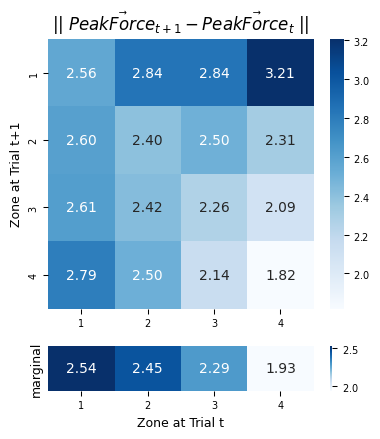

In [142]:
# Create a figure with 2 subplots arranged vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4.5), height_ratios=[6, 1])

# Plot the main heatmap on the top subplot
heatmap_data = grouped_distances.pivot(index='second_zone', columns='first_zone', values='Force_Distance')
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Blues", ax=ax1)
ax1.set_title(r'|| $\vec{Peak Force}_{t+1} - \vec{Peak Force}_{t}$ ||')
ax1.set_ylabel('Zone at Trial t+1')
ax1.set_xlabel('Zone at Trial t')
ax1.set_xlabel(None)


# Plot the marginal heatmap on the bottom subplot
marginal_heatmap_data = grouped_marginal_distances['temp'] = 1  # Dummy column for pivoting
marginal_heatmap_data = grouped_marginal_distances.pivot(index='temp', columns='first_zone', values='Force_Distance')
sns.heatmap(marginal_heatmap_data, annot=True, fmt=".2f", cmap="Blues", ax=ax2)
# ax2.set_title('Marginal')
ax2.set_ylabel('marginal')
ax2.set_yticks([])  # Hide y-axis ticks for the marginal heatmap
ax2.set_xlabel('Zone at Trial t')

plt.tight_layout()
plt.savefig(path_figs + 'peak_force_distance_vs_zone_all_points.pdf', bbox_inches='tight', dpi=300)

Text(12.222242472222229, 0.5, 'Zone at Trial t+1')

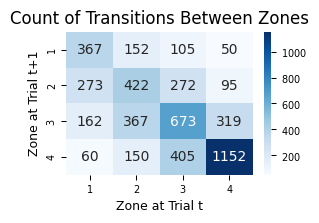

In [312]:
heatmap_data = grouped_distances.pivot(index='second_zone', columns='first_zone', values='count')
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Blues")
plt.title('Count of Transitions Between Zones')
plt.xlabel('Zone at Trial t')
plt.ylabel('Zone at Trial t+1')


### Cosine distances

In [143]:
# calculate distance of forces based on their trial distance for each subject
distances = []

forces_wide_correct = forces_wide[forces_wide['points'] != -1]
forces_wide_correct = forces_wide_correct.sort_values(by = ['SubNum' , 'BN', 'TN'])

# filter out subnum 8
# forces_wide_correct = forces_wide_correct[forces_wide_correct['SubNum'] != 8]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            for i in range(len(block_data) - 1):
                trial1 = block_data.iloc[i]
                trial2 = block_data.iloc[i + 1]
                if trial2['N'] - trial1['N'] == 1:  # only consider consecutive trials
                    # Calculate cosine distance of forces
                    force_dist = 1 - np.dot(trial2['force_vector'], trial1['force_vector']) / (np.linalg.norm(trial2['force_vector']) * np.linalg.norm(trial1['force_vector']))
                    # Calculate ETs
                    first_ET = trial1['ET']
                    second_ET = trial2['ET']
                    # Calculate zones
                    first_zone = trial1['zone']
                    second_zone = trial2['zone']

                    distances.append({
                        'SubNum': subind,
                        'Force_Distance': force_dist,
                        'first_ET': first_ET,
                        'second_ET': second_ET,
                        'first_zone': first_zone,
                        'second_zone': second_zone,
                        'day': day
                    })

# Concatenate all distances into a single DataFrame
distances_df = pd.DataFrame(distances)

distances_df['count'] = 1


100%|██████████| 11/11 [00:16<00:00,  1.53s/it]


In [144]:
grouped_distances = distances_df.groupby(['SubNum', 'first_zone', 'second_zone']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

grouped_distances = grouped_distances.groupby(['first_zone', 'second_zone']).agg({
    'Force_Distance': 'mean',
    'count': 'sum'
}).reset_index()

grouped_marginal_distances = distances_df.groupby(['SubNum', 'first_zone']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

grouped_marginal_distances = grouped_marginal_distances.groupby(['first_zone']).agg({
    'Force_Distance': 'mean',
    'count': 'sum'
}).reset_index()



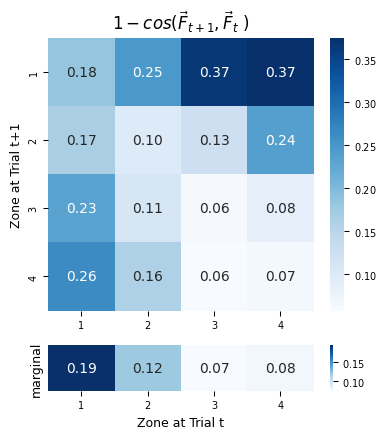

In [145]:
# Create a figure with 2 subplots arranged vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 4.5), height_ratios=[6, 1])

# Plot the main heatmap on the top subplot
heatmap_data = grouped_distances.pivot(index='second_zone', columns='first_zone', values='Force_Distance')
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Blues", ax=ax1)
ax1.set_title(r'$ 1 - cos(\vec{F}_{t+1}, \vec{F}_{t}$ )')
ax1.set_ylabel('Zone at Trial t+1')
ax1.set_xlabel('Zone at Trial t')
ax1.set_xlabel(None)


# Plot the marginal heatmap on the bottom subplot
marginal_heatmap_data = grouped_marginal_distances['temp'] = 1  # Dummy column for pivoting
marginal_heatmap_data = grouped_marginal_distances.pivot(index='temp', columns='first_zone', values='Force_Distance')
sns.heatmap(marginal_heatmap_data, annot=True, fmt=".2f", cmap="Blues", ax=ax2)
# ax2.set_title('Marginal')
ax2.set_ylabel('marginal')
ax2.set_yticks([])  # Hide y-axis ticks for the marginal heatmap
ax2.set_xlabel('Zone at Trial t')

plt.tight_layout()

plt.savefig(path_figs + 'cosine_distance_vs_zone_all_points.pdf', bbox_inches='tight', dpi=300)

Text(12.222242472222229, 0.5, 'Zone at Trial t+1')

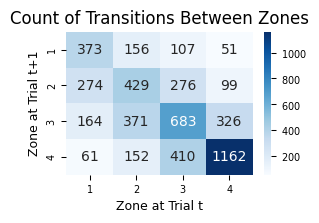

In [9]:
heatmap_data = grouped_distances.pivot(index='second_zone', columns='first_zone', values='count')
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Blues")
plt.title('Count of Transitions Between Zones')
plt.xlabel('Zone at Trial t')
plt.ylabel('Zone at Trial t+1')


Bin 1:
TtestResult(statistic=-0.3744514685247041, pvalue=0.715886596176541, df=10)
Bin 2:
TtestResult(statistic=2.787953937024887, pvalue=0.019187009899054995, df=10)
                     Anova
                   F Value Num DF  Den DF Pr > F
------------------------------------------------
ET_diff_bin        22.9434 1.0000 10.0000 0.0007
is_pos              9.5402 1.0000 10.0000 0.0115
ET_diff_bin:is_pos  5.8602 1.0000 10.0000 0.0360



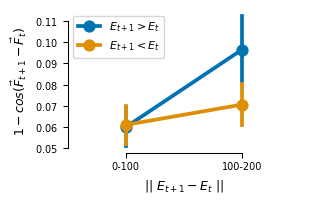

In [15]:
distances_df['is_pos'] = distances_df['second_ET'] > distances_df['first_ET']
distances_df['ET_Distance'] = np.abs(distances_df['second_ET'] - distances_df['first_ET'])

distances_df = distances_df[distances_df['ET_Distance'] < 200]

ET_diff_bin_size = 100

distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'is_pos']).agg({'Force_Distance': 'median',
                                                                                   'count': 'sum'}).reset_index()

# Fix hue order so legend ordering is stable
hue_order = [True, False]
ax = sns.pointplot(
    data=grouped_distances,
    x='ET_diff_bin',
    y='Force_Distance',
    errorbar='se',
    hue='is_pos',
    hue_order=hue_order
)
plt.xlabel(r'|| $E_{t+1} - E_{t}$ ||')
plt.ylabel(r'$1 - cos(\vec{F}_{t+1} - \vec{F}_{t})$')



# Remap legend labels without breaking color mapping
handles, labels = ax.get_legend_handles_labels()
label_map = {'True': r'$E_{t+1} > E_{t}$', 'False': r'$E_{t+1} < E_{t}$'}
ax.legend(handles, [label_map[l] for l in labels], title='')


# Create bin labels showing the actual intervals
bin_labels = []
for bin_num in sorted(grouped_distances['ET_diff_bin'].unique()):
    lower = (bin_num - 1) * ET_diff_bin_size
    upper = bin_num * ET_diff_bin_size
    bin_labels.append(f'{lower}-{upper}')
plt.xticks(range(len(bin_labels)), bin_labels)
    
sns.despine(trim=True)

plt.savefig(path_figs + 'force_distance_vs_ET_distance_pos_neg.pdf', bbox_inches='tight', dpi=300)

for bin in grouped_distances['ET_diff_bin'].unique():
    # if len(grouped_distances[grouped_distances['ET_diff_bin'] == bin]) < (2 * 11):
    if len(grouped_distances[grouped_distances['ET_diff_bin'] == bin]) < (2 * 10):
        print(f'Skipping bin {bin} due to insufficient data')
        # print(grouped_distances[grouped_distances['ET_diff_bin'] == bin])
        continue
    print(f'Bin {bin}:')
    print(stats.ttest_rel(
        grouped_distances[(grouped_distances['ET_diff_bin'] == bin) & (grouped_distances['is_pos'] == True)]['Force_Distance'],
        grouped_distances[(grouped_distances['ET_diff_bin'] == bin) & (grouped_distances['is_pos'] == False)]['Force_Distance']
    ))

print(AnovaRM(grouped_distances, 'Force_Distance', 'SubNum', within=['ET_diff_bin', 'is_pos']).fit())

### Error trials distance analysis

TtestResult(statistic=-4.491166149261464, pvalue=0.0011588233473880925, df=10)

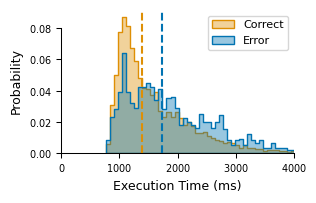

In [170]:
# Error trials are slower than correct trials

all_trials_ET = forces_wide[['SubNum', 'points', 'ET']].copy()
all_trials_ET['is_correct'] = all_trials_ET['points'] != -1
sns.histplot(data = all_trials_ET, x = 'ET', bins = 200, hue='is_correct', stat='probability', multiple = 'layer', kde = False, common_norm=False, alpha = 0.4,
             element='step', palette='colorblind')
plt.xlim(0, 4000)
ET_grouped = all_trials_ET.groupby('is_correct').agg({
    'ET': 'median'
}).reset_index()
plt.axvline(ET_grouped[ET_grouped['is_correct'] == True]['ET'].values[0], color=sns.color_palette("colorblind")[1], linestyle='--', label='Correct Median')
plt.axvline(ET_grouped[ET_grouped['is_correct'] == False]['ET'].values[0], color=sns.color_palette("colorblind")[0], linestyle='--', label='Error Median')
plt.xlabel('Execution Time (ms)')

legend_labels = ['Correct', 'Error']
plt.legend(legend_labels)

sns.despine(trim=True)
plt.savefig(path_figs + 'ET_histogram_correct_vs_error.pdf', bbox_inches='tight', dpi=300)

ET_grouped = all_trials_ET.groupby(['SubNum', 'is_correct']).agg({
    'ET': 'median'
}).reset_index()
stats.ttest_rel(ET_grouped[ET_grouped['is_correct'] == True]['ET'], ET_grouped[ET_grouped['is_correct'] == False]['ET'])

/var/folders/wg/16zn32014z5grhdv06dk49f00000gn/T/ipykernel_74558/3590696305.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  all_trials_ET = all_trials_ET.fillna(True)  # first trial of each subject has no previous trial, assume correct


TtestResult(statistic=4.096884348419347, pvalue=0.0021552973827057946, df=10)

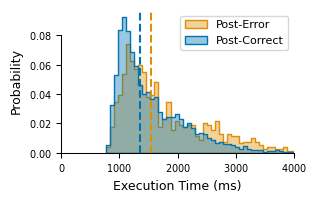

In [171]:
# Post error slowing analysis
all_trials_ET = forces_wide[['SubNum', 'N', 'points', 'ET']].copy()
all_trials_ET['is_correct'] = all_trials_ET['points'] != -1
all_trials_ET = all_trials_ET.sort_values(by = ['SubNum', 'N'])
all_trials_ET['prev_is_correct'] = all_trials_ET.groupby('SubNum')['is_correct'].shift(1)
all_trials_ET = all_trials_ET.fillna(True)  # first trial of each subject has no previous trial, assume correct
all_trials_ET['is_post_error'] = (all_trials_ET['prev_is_correct'] == False) & (all_trials_ET['is_correct'] == True)
all_trials_ET = all_trials_ET[all_trials_ET['is_correct'] == True]  # only consider correct trials
sns.histplot(data = all_trials_ET, x = 'ET', bins = 200, hue='is_post_error', stat='probability', multiple = 'layer', kde = False, common_norm=False, alpha = 0.4,
             element='step', palette='colorblind')
plt.xlim(0, 4000)
ET_grouped = all_trials_ET.groupby('is_post_error').agg({
    'ET': 'median'
}).reset_index()
plt.axvline(ET_grouped[ET_grouped['is_post_error'] == False]['ET'].values[0], color=sns.color_palette("colorblind")[0], linestyle='--', label='Post-Correct Median')
plt.axvline(ET_grouped[ET_grouped['is_post_error'] == True]['ET'].values[0], color=sns.color_palette("colorblind")[1], linestyle='--', label='Post-Error Median')
plt.xlabel('Execution Time (ms)')

legend_labels = ['Post-Error', 'Post-Correct']
plt.legend(legend_labels)
sns.despine(trim=True)

plt.savefig(path_figs + 'ET_histogram_post_error_vs_post_correct.pdf', bbox_inches='tight', dpi=300)

ET_grouped = all_trials_ET.groupby(['SubNum', 'is_post_error']).agg({
    'ET': 'median'
}).reset_index()
stats.ttest_rel(ET_grouped[ET_grouped['is_post_error'] == True]['ET'], ET_grouped[ET_grouped['is_post_error'] == False]['ET'])


In [134]:
# calculate distance of forces based on their trial distance for each subject
distances = []

# forces_wide_correct = forces_wide[forces_wide['points'] != -1]
forces_wide_correct = forces_wide 

# filter out subnum 8
# forces_wide_correct = forces_wide_correct[forces_wide_correct['SubNum'] != 8]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            for i in range(len(block_data) - 2):
                trial1 = block_data.iloc[i]
                trial2 = block_data.iloc[i + 1]
                trial3 = block_data.iloc[i + 2]
                if (trial2['N'] - trial1['N'] == 1) and (trial3['N'] - trial2['N'] == 1):  # only consider triple of consecutive trials
                    if (trial1['points'] != -1) and (trial3['points'] != -1):  # only consider if trial 1 and 3 are correct
                        # Calculate force distance
                        force_dist = np.linalg.norm(trial3['force_vector'] - trial1['force_vector'])
                        et_dist = trial3['ET'] - trial1['ET']
                        error_in_the_middle = (trial2['points'] == -1)

                        distances.append({
                            'SubNum': subind,
                            'Force_Distance': force_dist,
                            'ET_Distance': et_dist,
                            'day': day,
                            'error_in_the_middle': error_in_the_middle
                        })

# Concatenate all distances into a single DataFrame
distances_df = pd.DataFrame(distances)

distances_df['count'] = 1


# distances_df = distances_df[distances_df['ET_Distance'] < 400]
distances_df = distances_df[np.abs(distances_df['ET_Distance']) < 400]
# distances_df = distances_df[distances_df['ET_Distance'] < 200]
# distances_df = distances_df[np.abs(distances_df['ET_Distance']) < 200]




100%|██████████| 11/11 [00:06<00:00,  1.68it/s]


<Axes: xlabel='ET_Distance', ylabel='Force_Distance'>

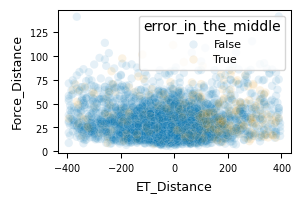

In [136]:
# plt.figure(figsize=(6, 5))
sns.scatterplot(data=distances_df, x='ET_Distance', y='Force_Distance', alpha = 0.1, hue = 'error_in_the_middle', palette = 'colorblind')


In [45]:
# ET_diff_bin_size = 200
# ET_diff_bin_size = 100
ET_diff_bin_size = 400

distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'error_in_the_middle']).agg({'Force_Distance': 'median',
                                                                                   'count': 'sum'}).reset_index()
grouped_distances[grouped_distances['error_in_the_middle'] == True]

,SubNum,ET_diff_bin,error_in_the_middle,Force_Distance,count
1,1,0,True,33.607868,19
3,1,1,True,39.011557,23
5,2,0,True,38.715241,18
7,2,1,True,34.874402,42
9,3,0,True,27.099305,18
11,3,1,True,23.548041,22
13,4,0,True,38.822982,18
15,4,1,True,28.266381,26
17,5,0,True,19.138959,12
19,5,1,True,17.407286,18


Bin 0:
TtestResult(statistic=2.631094235161841, pvalue=0.02511494189810674, df=10)
Bin 1:
TtestResult(statistic=1.9994705187794921, pvalue=0.07345281278495698, df=10)


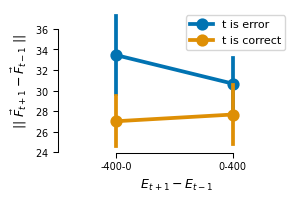

In [137]:
# ET_diff_bin_size = 200
# ET_diff_bin_size = 100
ET_diff_bin_size = 400


distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin','error_in_the_middle']).agg({'Force_Distance': 'median',
                                                                                   'count': 'sum'}).reset_index()



# sns.catplot(data=grouped_distances, x='ET_diff_bin', y='Force_Distance', hue = 'is_first_error',  col = 'is_pos', kind = 'point', errorbar = 'se')


# Fix hue order so legend ordering is stable
hue_order = [True, False]
ax = sns.pointplot(
    data=grouped_distances,
    x='ET_diff_bin',
    y='Force_Distance',
    errorbar='se',
    hue = 'error_in_the_middle',

    hue_order=hue_order
)
plt.xlabel(r' $E_{t+1} - E_{t-1}$')
plt.ylabel(r'|| $\vec{F}_{t+1} - \vec{F}_{t-1}$ ||')



# Remap legend labels without breaking color mapping
handles, labels = ax.get_legend_handles_labels()
label_map = {'True': 't is error', 'False': 't is correct'}
ax.legend(handles, [label_map[l] for l in labels], title='')


# Create bin labels showing the actual intervals
bin_labels = []
for bin_num in sorted(grouped_distances['ET_diff_bin'].unique()):
    lower = (bin_num - 1) * ET_diff_bin_size
    upper = bin_num * ET_diff_bin_size
    bin_labels.append(f'{lower}-{upper}')
plt.xticks(range(len(bin_labels)), bin_labels)
    
sns.despine(trim=True)

plt.savefig(path_figs + 'force_distance_vs_ET_distance_error_in_the_middle.pdf', bbox_inches='tight', dpi=300)

for bin in grouped_distances['ET_diff_bin'].unique():
    if len(grouped_distances[grouped_distances['ET_diff_bin'] == bin]) < (2 * 11):
    # if len(grouped_distances[grouped_distances['ET_diff_bin'] == bin]) < (2 * 10):
        print(f'Skipping bin {bin} due to insufficient data')
        # print(grouped_distances[grouped_distances['ET_diff_bin'] == bin])
        continue
    print(f'Bin {bin}:')
    print(stats.ttest_rel(
        grouped_distances[(grouped_distances['ET_diff_bin'] == bin) & (grouped_distances['error_in_the_middle'] == True)]['Force_Distance'],
        grouped_distances[(grouped_distances['ET_diff_bin'] == bin) & (grouped_distances['error_in_the_middle'] == False)]['Force_Distance']
    ))

# print(AnovaRM(grouped_distances, 'Force_Distance', 'SubNum', within=['ET_diff_bin', 'is_first_error']).fit())


In [380]:
# calculate distance of forces based on their trial distance for each subject
distances = []

# forces_wide_correct = forces_wide[forces_wide['points'] != -1]
forces_wide_correct = forces_wide 

# filter out subnum 8
# forces_wide_correct = forces_wide_correct[forces_wide_correct['SubNum'] != 8]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            for i in range(len(block_data) - 2):
                trial1 = block_data.iloc[i]
                trial2 = block_data.iloc[i + 1]
                trial3 = block_data.iloc[i + 2]
                if (trial2['N'] - trial1['N'] == 1) and (trial3['N'] - trial2['N'] == 1):  # only consider triple of consecutive trials
                    if (trial1['points'] != -1) and (trial3['points'] != -1):  # only consider if trial 1 and 3 are correct
                        # Calculate force distance
                        force_dist = np.linalg.norm(trial3['force_vector'] - trial1['force_vector'])
                        et_dist = trial3['ET'] - trial1['ET']
                        error_in_the_middle = (trial2['points'] == -1)

                        distances.append({
                            'SubNum': subind,
                            'Force_Distance': force_dist,
                            'ET_Distance': et_dist,
                            'day': day,
                            'error_in_the_middle': error_in_the_middle
                        })

# Concatenate all distances into a single DataFrame
distances_df = pd.DataFrame(distances)

distances_df['count'] = 1

distances_df['ET_Distance'] = np.abs(distances_df['ET_Distance'])


# distances_df = distances_df[distances_df['ET_Distance'] < 400]
# distances_df = distances_df[distances_df['ET_Distance'] < 400]
distances_df = distances_df[distances_df['ET_Distance'] < 200]
# distances_df = distances_df[np.abs(distances_df['ET_Distance']) < 200]




100%|██████████| 11/11 [00:06<00:00,  1.68it/s]


In [341]:
# ET_diff_bin_size = 200
ET_diff_bin_size = 100
# ET_diff_bin_size = 400

distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'error_in_the_middle']).agg({'Force_Distance': 'median',
                                                                                   'count': 'sum'}).reset_index()
grouped_distances[grouped_distances['error_in_the_middle'] == True]

,SubNum,ET_diff_bin,error_in_the_middle,Force_Distance,count
1,1,1,True,37.735825,24
3,1,2,True,28.094341,9
5,2,1,True,35.417680,30
7,2,2,True,32.608462,20
9,3,1,True,22.117650,24
11,3,2,True,24.651654,10
13,4,1,True,36.412677,23
15,4,2,True,28.058645,14
17,5,1,True,15.314046,17
19,5,2,True,19.789480,9


Bin 1:
TtestResult(statistic=1.9822736927051172, pvalue=0.07558624750982203, df=10)
Bin 2:
TtestResult(statistic=2.8846958103137528, pvalue=0.0162542148374145, df=10)
                            Anova
                                F Value Num DF  Den DF Pr > F
-------------------------------------------------------------
ET_diff_bin                      0.3667 1.0000 10.0000 0.5583
error_in_the_middle             15.3419 1.0000 10.0000 0.0029
ET_diff_bin:error_in_the_middle  0.0256 1.0000 10.0000 0.8761



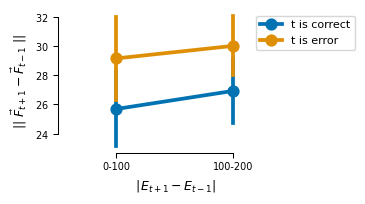

In [385]:
# ET_diff_bin_size = 200
ET_diff_bin_size = 100
# ET_diff_bin_size = 400


distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin','error_in_the_middle']).agg({'Force_Distance': 'median',
                                                                                   'count': 'sum'}).reset_index()



# sns.catplot(data=grouped_distances, x='ET_diff_bin', y='Force_Distance', hue = 'is_first_error',  col = 'is_pos', kind = 'point', errorbar = 'se')


# Fix hue order so legend ordering is stable
hue_order = [False, True]
ax = sns.pointplot(
    data=grouped_distances,
    x='ET_diff_bin',
    y='Force_Distance',
    errorbar='se',
    hue = 'error_in_the_middle',

    hue_order=hue_order
)
plt.xlabel(r' $|E_{t+1} - E_{t-1}|$')
plt.ylabel(r'|| $\vec{F}_{t+1} - \vec{F}_{t-1}$ ||')



# Remap legend labels without breaking color mapping
handles, labels = ax.get_legend_handles_labels()
label_map = {'True': 't is error', 'False': 't is correct'}
ax.legend(handles, [label_map[l] for l in labels], title='', loc='upper right', bbox_to_anchor=(1.3, 1))


# Create bin labels showing the actual intervals
bin_labels = []
for bin_num in sorted(grouped_distances['ET_diff_bin'].unique()):
    lower = (bin_num - 1) * ET_diff_bin_size
    upper = bin_num * ET_diff_bin_size
    bin_labels.append(f'{lower}-{upper}')
plt.xticks(range(len(bin_labels)), bin_labels)
    
sns.despine(trim=True)

plt.savefig(path_figs + 'force_distance_vs_ET_distance_error_in_the_middle.pdf', bbox_inches='tight', dpi=300)

for bin in grouped_distances['ET_diff_bin'].unique():
    if len(grouped_distances[grouped_distances['ET_diff_bin'] == bin]) < (2 * 11):
    # if len(grouped_distances[grouped_distances['ET_diff_bin'] == bin]) < (2 * 10):
        print(f'Skipping bin {bin} due to insufficient data')
        # print(grouped_distances[grouped_distances['ET_diff_bin'] == bin])
        continue
    print(f'Bin {bin}:')
    print(stats.ttest_rel(
        grouped_distances[(grouped_distances['ET_diff_bin'] == bin) & (grouped_distances['error_in_the_middle'] == True)]['Force_Distance'],
        grouped_distances[(grouped_distances['ET_diff_bin'] == bin) & (grouped_distances['error_in_the_middle'] == False)]['Force_Distance']
    ))

print(AnovaRM(grouped_distances, 'Force_Distance', 'SubNum', within=['ET_diff_bin', 'error_in_the_middle']).fit())


In [4]:
# calculate distance of forces based on their trial distance for each subject
distances = []

# forces_wide_correct = forces_wide[forces_wide['points'] != -1]
forces_wide_correct = forces_wide 

# filter out subnum 8
# forces_wide_correct = forces_wide_correct[forces_wide_correct['SubNum'] != 8]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            for i in range(len(block_data) - 2):
                trial1 = block_data.iloc[i]
                trial2 = block_data.iloc[i + 1]
                trial3 = block_data.iloc[i + 2]
                if (trial2['N'] - trial1['N'] == 1) and (trial3['N'] - trial2['N'] == 1):  # only consider triple of consecutive trials
                    if (trial1['points'] != -1) and (trial3['points'] != -1):  # only consider if trial 1 and 3 are correct
                        # Calculate force distance
                        force_dist = np.linalg.norm(trial3['force_vector'] - trial1['force_vector'])
                        et_dist = trial3['ET'] - trial1['ET']
                        error_in_the_middle = (trial2['points'] == -1)

                        distances.append({
                            'SubNum': subind,
                            'Force_Distance': force_dist,
                            'Force_Distance_first_to_second': np.linalg.norm(trial2['force_vector'] - trial1['force_vector']),
                            'Force_Distance_second_to_third': np.linalg.norm(trial3['force_vector'] - trial2['force_vector']),
                            'ET_Distance': et_dist,
                            'day': day,
                            'error_in_the_middle': error_in_the_middle
                        })

# Concatenate all distances into a single DataFrame
distances_df = pd.DataFrame(distances)

distances_df['count'] = 1

distances_df['ET_Distance'] = np.abs(distances_df['ET_Distance'])


# distances_df = distances_df[distances_df['ET_Distance'] < 400]
# distances_df = distances_df[distances_df['ET_Distance'] < 400]
# distances_df = distances_df[distances_df['ET_Distance'] < 200]
# distances_df = distances_df[np.abs(distances_df['ET_Distance']) < 200]
distances_df = distances_df[distances_df['ET_Distance'] < 1000]




100%|██████████| 11/11 [00:06<00:00,  1.64it/s]


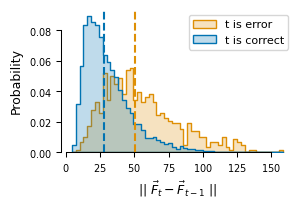

In [ ]:
sns.histplot(distances_df, x = 'Force_Distance_first_to_second', hue = 'error_in_the_middle', element = 'step', stat = 'probability', common_norm = False, palette = 'colorblind',
             )
grouped_distances = distances_df.groupby(['SubNum', 'error_in_the_middle']).agg({'Force_Distance_first_to_second': 'median'}).reset_index()
plt.axvline(grouped_distances[grouped_distances['error_in_the_middle'] == False]['Force_Distance_first_to_second'].median(), color=sns.color_palette("colorblind")[0], linestyle='--', label='t is correct Median')
plt.axvline(grouped_distances[grouped_distances['error_in_the_middle'] == True]['Force_Distance_first_to_second'].median(), color=sns.color_palette("colorblind")[1], linestyle='--', label='t is error Median')
plt.xlabel(r'|| $\vec{F}_{t} - \vec{F}_{t-1}$ ||')
legend_labels = ['t is error', 't is correct']
plt.legend(legend_labels)
sns.despine(trim=True)


TtestResult(statistic=4.99291029235253, pvalue=0.0005429800676878882, df=10)
effect size: 5.37086443378303


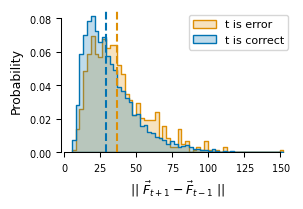

In [31]:
sns.histplot(distances_df, x = 'Force_Distance', hue = 'error_in_the_middle', element = 'step', stat = 'probability', common_norm = False, palette = 'colorblind',
             )
grouped_distances = distances_df.groupby(['SubNum', 'error_in_the_middle']).agg({'Force_Distance': 'median'}).reset_index()
plt.axvline(grouped_distances[grouped_distances['error_in_the_middle'] == False]['Force_Distance'].median(), color=sns.color_palette("colorblind")[0], linestyle='--', label='t is correct Median')
plt.axvline(grouped_distances[grouped_distances['error_in_the_middle'] == True]['Force_Distance'].median(), color=sns.color_palette("colorblind")[1], linestyle='--', label='t is error Median')
plt.xlabel(r'|| $\vec{F}_{t+1} - \vec{F}_{t-1}$ ||')
legend_labels = ['t is error', 't is correct']
plt.legend(legend_labels)
sns.despine(trim=True)

plt.savefig(path_figs + 'force_distance_pre_post_error.pdf', bbox_inches='tight', dpi=300)

print(stats.ttest_rel(
    grouped_distances[grouped_distances['error_in_the_middle'] == True]['Force_Distance'],
    grouped_distances[grouped_distances['error_in_the_middle'] == False]['Force_Distance']
))
print('effect size:', np.mean(grouped_distances[grouped_distances['error_in_the_middle'] == True]['Force_Distance']) - np.mean(grouped_distances[grouped_distances['error_in_the_middle'] == False]['Force_Distance']))

TtestResult(statistic=3.391984410444126, pvalue=0.00686290376143256, df=10)
effect size: 31.36


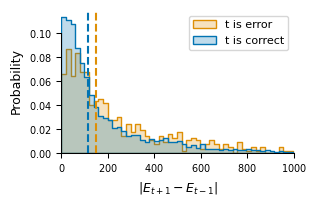

In [34]:
sns.histplot(data = distances_df, x = 'ET_Distance', hue = 'error_in_the_middle', element= 'step', stat = 'probability', common_norm = False, palette = 'colorblind',
             bins = 50)
grouped_distances = distances_df.groupby(['SubNum', 'error_in_the_middle']).agg({'ET_Distance': 'median'}).reset_index()
plt.axvline(grouped_distances[grouped_distances['error_in_the_middle'] == False]['ET_Distance'].mean(), color=sns.color_palette("colorblind")[0], linestyle='--', label='t is correct Median')
plt.axvline(grouped_distances[grouped_distances['error_in_the_middle'] == True]['ET_Distance'].mean(), color=sns.color_palette("colorblind")[1], linestyle='--', label='t is error Median')
plt.xlabel(r'$|E_{t+1} - E_{t-1}|$')
legend_labels = ['t is error', 't is correct']
plt.legend(legend_labels)
sns.despine(trim=True)
plt.xlim(0, 1000)

plt.savefig(path_figs + 'ET_distance_pre_post_error.pdf', bbox_inches='tight', dpi=300)

print(stats.ttest_rel(
    grouped_distances[grouped_distances['error_in_the_middle'] == True]['ET_Distance'],
    grouped_distances[grouped_distances['error_in_the_middle'] == False]['ET_Distance']
))
print('effect size:', np.round(np.mean(grouped_distances[grouped_distances['error_in_the_middle'] == True]['ET_Distance']) - np.mean(grouped_distances[grouped_distances['error_in_the_middle'] == False]['ET_Distance']), 2))


TtestResult(statistic=8.349733055030725, pvalue=8.078959443259136e-06, df=10)

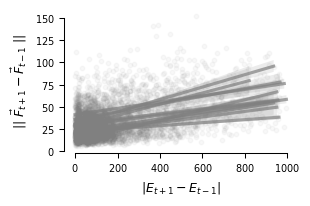

In [378]:
import statsmodels.api as sm
slopes = []

for subid, subdata in distances_df.groupby(['SubNum']):
    sns.regplot(data=subdata, x='ET_Distance', y='Force_Distance', scatter = True, color = 'gray', line_kws={'alpha':0.7}, scatter_kws={'alpha':0.05, 's':10})
    # fit OLS model
    X = subdata['ET_Distance']
    Y = subdata['Force_Distance']
    X = sm.add_constant(X)  # Adds a constant term to the predictor
    model = sm.OLS(Y, X).fit()
    intercept, slope = model.params
    slopes.append(slope)

# plt.ylim(0, 60)
sns.despine(trim=True)
plt.xlabel(r'$|E_{t+1} - E_{t-1}|$')
plt.ylabel(r'|| $\vec{F}_{t+1} - \vec{F}_{t-1}$ ||')
plt.savefig(path_figs + 'force_distance_vs_ET_distance_pre_post.pdf', bbox_inches='tight', dpi=300)

stats.ttest_1samp(slopes, 0)

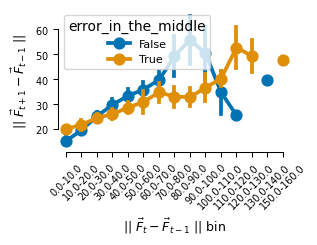

In [206]:
delta_f_bin = 10
distances_df = distances_df.copy()
# distances_df = distances_df[distances_df['error_in_the_middle'] == False]
distances_df['Force_Distance_first_to_second_bin'] = (distances_df['Force_Distance_first_to_second'] // delta_f_bin) + 1

grouped_distances = distances_df.groupby(['SubNum', 'Force_Distance_first_to_second_bin', 'error_in_the_middle']).agg({
    'Force_Distance': 'median',
    'count': 'sum'
}).reset_index()

sns.pointplot(data = grouped_distances, x = 'Force_Distance_first_to_second_bin', y = 'Force_Distance', errorbar = 'se', hue = 'error_in_the_middle')

plt.xlabel(r'|| $\vec{F}_{t} - \vec{F}_{t-1}$ || bin')
plt.ylabel(r'|| $\vec{F}_{t+1} - \vec{F}_{t-1}$ ||')

xlabels = []
for bin in sorted(grouped_distances['Force_Distance_first_to_second_bin'].unique()):
    lower = (bin - 1) * delta_f_bin
    upper = bin * delta_f_bin
    xlabels.append(f'{lower}-{upper}')
plt.xticks(range(len(xlabels)), xlabels, rotation=45)

# plt.xlim()
sns.despine(trim=True)



In [ ]:
grouped_distances

,SubNum,Force_Distance_first_to_second_bin,error_in_the_middle,Force_Distance,count
0,1,2.0,False,21.735348,50
1,1,3.0,False,26.399266,91
2,1,3.0,True,31.538287,4
3,1,4.0,False,33.345964,75
4,1,4.0,True,27.775756,8
...,...,...,...,...,...
181,11,8.0,True,31.174118,7
182,11,9.0,False,37.349417,6
183,11,9.0,True,45.145319,1
184,11,10.0,False,31.980920,3


In [26]:
# calculate distance of forces based on their trial distance for each subject
distances = []

# forces_wide_correct = forces_wide[forces_wide['points'] != -1]
forces_wide_correct = forces_wide 

# filter out subnum 8
# forces_wide_correct = forces_wide_correct[forces_wide_correct['SubNum'] != 8]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            for i in range(len(block_data) - 2):
                trial1 = block_data.iloc[i]
                trial2 = block_data.iloc[i + 1]
                trial3 = block_data.iloc[i + 2]
                if (trial2['N'] - trial1['N'] == 1) and (trial3['N'] - trial2['N'] == 1):  # only consider triple of consecutive trials
                    if (trial1['points'] != -1) and (trial3['points'] != -1):  # only consider if trial 1 and 3 are correct
                        # Calculate force distance
                        force_dist = np.linalg.norm(trial3['force_vector'] - trial1['force_vector'])
                        et_dist = trial3['ET'] - trial1['ET']
                        error_in_the_middle = (trial2['points'] == -1)

                        distances.append({
                            'SubNum': subind,
                            'Force_Distance': force_dist,
                            'Force_Distance_first_to_second': np.linalg.norm(trial2['force_vector'] - trial1['force_vector']),
                            'Force_Distance_second_to_third': np.linalg.norm(trial3['force_vector'] - trial2['force_vector']),
                            'ET_Distance': et_dist,
                            'day': day,
                            'error_in_the_middle': error_in_the_middle
                        })

# Concatenate all distances into a single DataFrame
distances_df = pd.DataFrame(distances)

distances_df['count'] = 1


# distances_df = distances_df[distances_df['ET_Distance'] < 400]
# distances_df = distances_df[distances_df['ET_Distance'] < 400]
# distances_df = distances_df[distances_df['ET_Distance'] < 200]
distances_df = distances_df[np.abs(distances_df['ET_Distance']) < 200]
# distances_df = distances_df[np.abs(distances_df['ET_Distance']) < 1000]





100%|██████████| 11/11 [00:06<00:00,  1.65it/s]


<Axes: xlabel='Force_Distance', ylabel='Count'>

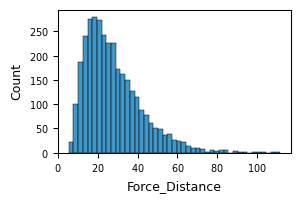

In [27]:
sns.histplot(distances_df, x = 'Force_Distance')

In [28]:
cut_off_percentile = 95
force_distance_cutoff = distances_df['Force_Distance'].quantile(cut_off_percentile / 100)
distances_df = distances_df[distances_df['Force_Distance'] <= force_distance_cutoff]

# exclude first day
# distances_df = distances_df[distances_df['day'] != 1]

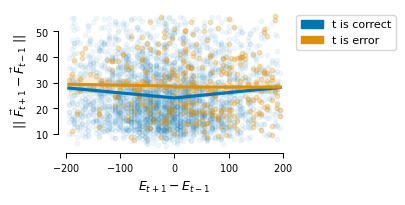

In [73]:
cmap = sns.color_palette("colorblind")
distances_df_positive = distances_df[distances_df['ET_Distance'] >= 0]
sns.regplot(data=distances_df_positive[distances_df_positive['error_in_the_middle'] == 0], x = 'ET_Distance', y = 'Force_Distance', scatter_kws={'alpha':0.05, 's':10}, line_kws={'alpha':1}, color = cmap[0])
sns.regplot(data=distances_df_positive[distances_df_positive['error_in_the_middle'] == 1], x = 'ET_Distance', y = 'Force_Distance', scatter_kws={'alpha':0.25, 's':10}, line_kws={'alpha':1}, color = cmap[1])

distances_df_negative = distances_df[distances_df['ET_Distance'] < 0]
sns.regplot(data=distances_df_negative[distances_df_negative['error_in_the_middle'] == 0], x = 'ET_Distance', y = 'Force_Distance', scatter_kws={'alpha':0.05, 's':10}, line_kws={'alpha':1}, color = cmap[0], label = 't is correct')
sns.regplot(data=distances_df_negative[distances_df_negative['error_in_the_middle'] == 1], x = 'ET_Distance', y = 'Force_Distance', scatter_kws={'alpha':0.25, 's':10}, line_kws={'alpha':1}, color = cmap[1], label = 't is error')

# Fix legend alpha
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color=cmap[0], label='t is correct', alpha=1),
    mpatches.Patch(color=cmap[1], label='t is error', alpha=1)
]
plt.legend(handles=handles, bbox_to_anchor=(1, 1), loc='upper left', title='')

plt.xlabel(r'$E_{t+1} - E_{t-1}$')
plt.ylabel(r'|| $\vec{F}_{t+1} - \vec{F}_{t-1}$ ||')

# plt.ylim(20,40)

sns.despine(trim=True)
plt.savefig(path_figs + 'force_distance_vs_ET_distance_pre_post_ANCOVA.pdf', bbox_inches='tight', dpi=300)

### Correct trials distance analysis

In [ ]:
# calculate distance of forces based on their trial distance for each subject
distances = []

forces_wide_correct = forces_wide[forces_wide['points'] != -1]

# filter out subnum 8
# forces_wide_correct = forces_wide_correct[forces_wide_correct['SubNum'] != 8]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            block_data = block_data[block_data['points'] != -1]
            for i in range(len(block_data) - 1):
                trial1 = block_data.iloc[i]
                trial2 = block_data.iloc[i + 1]
                if trial2['N'] - trial1['N'] == 1:  # only consider consecutive trials
                    # Calculate force distance
                    force_dist = np.linalg.norm(trial2['force_vector'] - trial1['force_vector'])
                    # Calculate ET distance
                    et_dist = abs(trial2['ET'] - trial1['ET'])
                    is_pos = (trial2['ET'] - trial1['ET']) > 0

                    distances.append({
                        'SubNum': subind,
                        'Force_Distance': force_dist,
                        'ET_Distance': et_dist,
                        'is_pos': is_pos,
                        'day': day
                    })

# Concatenate all distances into a single DataFrame
distances_df = pd.DataFrame(distances)

distances_df['count'] = 1


100%|██████████| 11/11 [00:03<00:00,  2.79it/s]


In [43]:
# calculate distance of forces based on their trial distance for each subject
distances = []

forces_wide_correct = forces_wide[forces_wide['points'] != -1]

# filter out subnum 8
# forces_wide_correct = forces_wide_correct[forces_wide_correct['SubNum'] != 8]

for subind, subdata in tqdm(forces_wide_correct.groupby('SubNum')):
    for day, day_data in subdata.groupby('day'):
        for block, block_data in day_data.groupby('BN'):
            for i in range(len(block_data) - 2):
                trial1 = block_data.iloc[i]
                trial2 = block_data.iloc[i + 1]
                trial3 = block_data.iloc[i + 2]
                if (trial2['N'] - trial1['N'] == 1) and (trial3['N'] - trial2['N'] == 1):  # only consider consecutive trials
                    # Calculate force distance
                    force_dist = np.linalg.norm(trial3['force_vector'] - trial2['force_vector'])
                    # Calculate ET distance
                    et_dist = abs(trial3['ET'] - trial2['ET'])
                    is_pos = (trial3['ET'] - trial2['ET']) > 0
                    et_dist_before = abs(trial2['ET'] - trial1['ET'])
                    is_pos_before = (trial2['ET'] - trial1['ET']) > 0

                    distances.append({
                        'SubNum': subind,
                        'Force_Distance': force_dist,
                        'ET_Distance': et_dist,
                        'is_pos': is_pos,
                        'day': day,
                        'ET_Distance_Before': et_dist_before,
                        'is_pos_Before': is_pos_before
                    })

# Concatenate all distances into a single DataFrame
distances_df = pd.DataFrame(distances)

distances_df['count'] = 1


100%|██████████| 11/11 [00:05<00:00,  1.96it/s]


In [44]:
# distances_df = distances_df[distances_df['ET_Distance'] < 800]
# distances_df = distances_df[distances_df['ET_Distance'] < 600]
# distances_df = distances_df[distances_df['ET_Distance'] < 400]
distances_df = distances_df[distances_df['ET_Distance'] < 200]

# distances_df = distances_df[distances_df['ET_Distance_Before'] < 600]
# distances_df = distances_df[distances_df['ET_Distance_Before'] < 400]
distances_df = distances_df[distances_df['ET_Distance_Before'] < 200]




TtestResult(statistic=-3.1126895398131347, pvalue=0.011010145177489446, df=10)

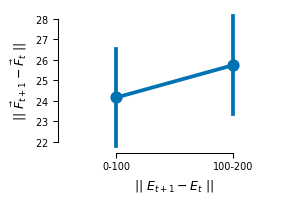

In [45]:
# ET_diff_bin_size = 200
ET_diff_bin_size = 100
# ET_diff_bin_size = 300


distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin']).agg({'Force_Distance': 'median',
                                                                         'count': 'sum'}).reset_index()

# Create bin labels showing the actual intervals
bin_labels = []
for bin_num in sorted(grouped_distances['ET_diff_bin'].unique()):
    lower = (bin_num - 1) * ET_diff_bin_size
    upper = bin_num * ET_diff_bin_size
    bin_labels.append(f'{lower}-{upper}')

sns.pointplot(data=grouped_distances, x='ET_diff_bin', y='Force_Distance', errorbar='se')
plt.xticks(range(len(bin_labels)), bin_labels)
plt.xlabel(r'|| $E_{t+1} - E_{t}$ ||')
plt.ylabel(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
sns.despine(trim=True)

plt.savefig(path_figs + 'force_distance_vs_ET_distance.pdf', bbox_inches='tight', dpi=300)


stats.ttest_rel(
    grouped_distances[grouped_distances['ET_diff_bin'] == 1]['Force_Distance'],
    grouped_distances[grouped_distances['ET_diff_bin'] == 2]['Force_Distance']
)


In [631]:
grouped_distances

,SubNum,ET_diff_bin,Force_Distance,count
0,1,1,28.174818,191
1,1,2,29.981597,65
2,2,1,25.446428,207
3,2,2,27.200856,47
4,3,1,19.788230,193
5,3,2,23.500792,53
6,4,1,26.531935,182
7,4,2,25.800134,79
8,5,1,12.234567,210
9,5,2,13.863652,77


Bin 1:
TtestResult(statistic=1.2334539276985907, pvalue=0.24561223837274904, df=10)
Bin 2:
TtestResult(statistic=3.3987420814610756, pvalue=0.006785399543372828, df=10)
                     Anova
                   F Value Num DF  Den DF Pr > F
------------------------------------------------
ET_diff_bin        21.2497 1.0000 10.0000 0.0010
is_pos             13.3941 1.0000 10.0000 0.0044
ET_diff_bin:is_pos  6.5653 1.0000 10.0000 0.0283



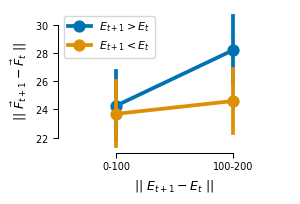

In [647]:
# ET_diff_bin_size = 200
ET_diff_bin_size = 100

distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'is_pos']).agg({'Force_Distance': 'median',
                                                                                   'count': 'sum'}).reset_index()

# Fix hue order so legend ordering is stable
hue_order = [True, False]
ax = sns.pointplot(
    data=grouped_distances,
    x='ET_diff_bin',
    y='Force_Distance',
    errorbar='se',
    hue='is_pos',
    hue_order=hue_order
)
plt.xlabel(r'|| $E_{t+1} - E_{t}$ ||')
plt.ylabel(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')



# Remap legend labels without breaking color mapping
handles, labels = ax.get_legend_handles_labels()
label_map = {'True': r'$E_{t+1} > E_{t}$', 'False': r'$E_{t+1} < E_{t}$'}
ax.legend(handles, [label_map[l] for l in labels], title='')


# Create bin labels showing the actual intervals
bin_labels = []
for bin_num in sorted(grouped_distances['ET_diff_bin'].unique()):
    lower = (bin_num - 1) * ET_diff_bin_size
    upper = bin_num * ET_diff_bin_size
    bin_labels.append(f'{lower}-{upper}')
plt.xticks(range(len(bin_labels)), bin_labels)
    
sns.despine(trim=True)

plt.savefig(path_figs + 'force_distance_vs_ET_distance_pos_neg.pdf', bbox_inches='tight', dpi=300)

for bin in grouped_distances['ET_diff_bin'].unique():
    # if len(grouped_distances[grouped_distances['ET_diff_bin'] == bin]) < (2 * 11):
    if len(grouped_distances[grouped_distances['ET_diff_bin'] == bin]) < (2 * 10):
        print(f'Skipping bin {bin} due to insufficient data')
        # print(grouped_distances[grouped_distances['ET_diff_bin'] == bin])
        continue
    print(f'Bin {bin}:')
    print(stats.ttest_rel(
        grouped_distances[(grouped_distances['ET_diff_bin'] == bin) & (grouped_distances['is_pos'] == True)]['Force_Distance'],
        grouped_distances[(grouped_distances['ET_diff_bin'] == bin) & (grouped_distances['is_pos'] == False)]['Force_Distance']
    ))

print(AnovaRM(grouped_distances, 'Force_Distance', 'SubNum', within=['ET_diff_bin', 'is_pos']).fit())


Bin 1:
TtestResult(statistic=1.293809468578632, pvalue=0.2248145827792067, df=10)
Bin 2:
TtestResult(statistic=0.24835437451033193, pvalue=0.8088859947603926, df=10)
                         Anova
                          F Value Num DF  Den DF Pr > F
-------------------------------------------------------
ET_diff_bin               11.4125 1.0000 10.0000 0.0070
is_pos_Before              0.8491 1.0000 10.0000 0.3785
ET_diff_bin:is_pos_Before  0.7317 1.0000 10.0000 0.4124



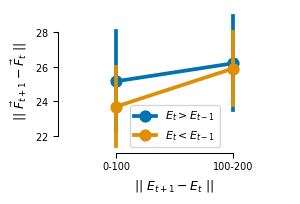

In [653]:
# ET_diff_bin_size = 200
ET_diff_bin_size = 100

distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'is_pos_Before']).agg({'Force_Distance': 'median',
                                                                                          'count': 'sum'}).reset_index()

# Fix hue order so legend ordering is stable
hue_order = [True, False]
ax = sns.pointplot(
    data=grouped_distances,
    x='ET_diff_bin',
    y='Force_Distance',
    errorbar='se',
    hue='is_pos_Before',
    hue_order=hue_order
)
plt.xlabel(r'|| $E_{t+1} - E_{t}$ ||')
plt.ylabel(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')



# Remap legend labels without breaking color mapping
handles, labels = ax.get_legend_handles_labels()
label_map = {'True': r'$E_{t} > E_{t-1}$', 'False': r'$E_{t} < E_{t-1}$'}
ax.legend(handles, [label_map[l] for l in labels], title='')


# Create bin labels showing the actual intervals
bin_labels = []
for bin_num in sorted(grouped_distances['ET_diff_bin'].unique()):
    lower = (bin_num - 1) * ET_diff_bin_size
    upper = bin_num * ET_diff_bin_size
    bin_labels.append(f'{lower}-{upper}')
plt.xticks(range(len(bin_labels)), bin_labels)
    
sns.despine(trim=True)

plt.savefig(path_figs + 'force_distance_vs_ET_distance_pos_neg_before.pdf', bbox_inches='tight', dpi=300)

for bin in grouped_distances['ET_diff_bin'].unique():
    # if len(grouped_distances[grouped_distances['ET_diff_bin'] == bin]) < (2 * 11):
    if len(grouped_distances[grouped_distances['ET_diff_bin'] == bin]) < (2 * 10):
        print(f'Skipping bin {bin} due to insufficient data')
        # print(grouped_distances[grouped_distances['ET_diff_bin'] == bin])
        continue
    print(f'Bin {bin}:')
    print(stats.ttest_rel(
        grouped_distances[(grouped_distances['ET_diff_bin'] == bin) & (grouped_distances['is_pos_Before'] == True)]['Force_Distance'],
        grouped_distances[(grouped_distances['ET_diff_bin'] == bin) & (grouped_distances['is_pos_Before'] == False)]['Force_Distance']
    ))

print(AnovaRM(grouped_distances, 'Force_Distance', 'SubNum', within=['ET_diff_bin', 'is_pos_Before']).fit())


In [634]:
grouped_distances

,SubNum,ET_diff_bin,is_pos_Before,Force_Distance,count
0,1,1,False,29.084289,126
1,1,1,True,27.383899,65
2,1,2,False,29.147146,31
3,1,2,True,33.547174,34
4,2,1,False,25.724444,120
5,2,1,True,24.340686,87
6,2,2,False,23.219409,22
7,2,2,True,29.355742,25
8,3,1,False,19.567930,112
9,3,1,True,20.410923,81


In [514]:
# ET_diff_bin_size = 200
# # ET_diff_bin_size = 100

# # distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
# distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance_Before'] // ET_diff_bin_size) + 1

# grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'is_pos_Before']).agg({'Force_Distance': 'median'}).reset_index()

# # Fix hue order so legend ordering is stable
# hue_order = [True, False]
# ax = sns.pointplot(
#     data=grouped_distances,
#     x='ET_diff_bin',
#     y='Force_Distance',
#     errorbar='se',
#     hue='is_pos_Before',
#     hue_order=hue_order
# )
# plt.xlabel(r'|| $E_{t} - E_{t-1}$ ||')
# plt.ylabel(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')



# # Remap legend labels without breaking color mapping
# handles, labels = ax.get_legend_handles_labels()
# label_map = {'True': r'$E_{t} > E_{t-1}$', 'False': r'$E_{t} < E_{t-1}$'}
# ax.legend(handles, [label_map[l] for l in labels], title='')


# # Create bin labels showing the actual intervals
# bin_labels = []
# for bin_num in sorted(grouped_distances['ET_diff_bin'].unique()):
#     lower = (bin_num - 1) * ET_diff_bin_size
#     upper = bin_num * ET_diff_bin_size
#     bin_labels.append(f'{lower}-{upper}')
# plt.xticks(range(len(bin_labels)), bin_labels)
    
# sns.despine(trim=True)

# for bin in grouped_distances['ET_diff_bin'].unique():
#     # if len(grouped_distances[grouped_distances['ET_diff_bin'] == bin]) < (2 * 11):
#     if len(grouped_distances[grouped_distances['ET_diff_bin'] == bin]) < (2 * 10):
#         print(f'Skipping bin {bin} due to insufficient data')
#         # print(grouped_distances[grouped_distances['ET_diff_bin'] == bin])
#         continue
#     print(f'Bin {bin}:')
#     print(stats.ttest_rel(
#         grouped_distances[(grouped_distances['ET_diff_bin'] == bin) & (grouped_distances['is_pos_Before'] == True)]['Force_Distance'],
#         grouped_distances[(grouped_distances['ET_diff_bin'] == bin) & (grouped_distances['is_pos_Before'] == False)]['Force_Distance']
#     ))

# print(AnovaRM(grouped_distances, 'Force_Distance', 'SubNum', within=['ET_diff_bin', 'is_pos_Before']).fit())


/var/folders/wg/16zn32014z5grhdv06dk49f00000gn/T/ipykernel_22527/678610980.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  distances_df.loc[:, 'ET_Distance_signed'] = distances_df['ET_Distance'] * distances_df['is_pos'].replace({False: -1, True: 1})
/var/folders/wg/16zn32014z5grhdv06dk49f00000gn/T/ipykernel_22527/678610980.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  distances_df.loc[:, 'ET_Distance_Before_signed'] = distances_df['ET_Distance_Before'] * distances_df['is_pos_Before'].replace({False: -1, True: 1})


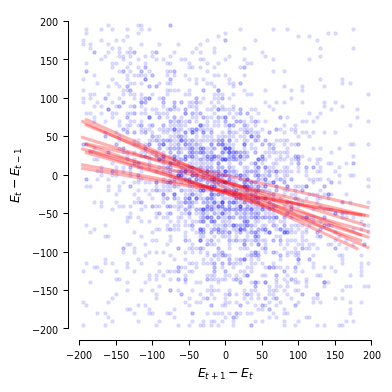

In [649]:
# ET_diff_bin_size = 200
ET_diff_bin_size = 100
distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
distances_df.loc[:, 'ET_Distance_signed'] = distances_df['ET_Distance'] * distances_df['is_pos'].replace({False: -1, True: 1})
distances_df.loc[:, 'ET_Distance_Before_signed'] = distances_df['ET_Distance_Before'] * distances_df['is_pos_Before'].replace({False: -1, True: 1})

# grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin']).agg({
#     'ET_Distance_signed': 'mean',
#     'ET_Distance_Before_signed': 'mean'
# })

sns.lmplot(data=distances_df, x='ET_Distance_signed', y = 'ET_Distance_Before_signed', height=4, aspect=1, legend=False, scatter_kws={'alpha':0.1, 's':5, 'color': 'blue'}, line_kws={'color':'red', 'alpha':0.3},
           hue = 'SubNum', ci = None)
plt.xlabel(r'$E_{t+1} - E_{t}$')
plt.ylabel(r'$E_{t} - E_{t-1}$')
sns.despine(trim=True)

plt.savefig(path_figs + 'ET_t_plus_1_minus_ET_t_vs_ET_t_minus_ET_t_minus_1.pdf', bbox_inches='tight', dpi=300)

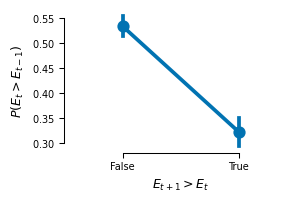

In [637]:
# ET_diff_bin_size = 200
ET_diff_bin_size = 100
distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
grouped_distances = distances_df.groupby(['SubNum', 'is_pos']).agg({
    'is_pos_Before': 'mean',
    'count': 'sum'
})

sns.pointplot(
    data=grouped_distances,
    x='is_pos',
    y='is_pos_Before',
    errorbar='se')

plt.xlabel(r'$E_{t+1} > E_{t}$')
plt.ylabel(r'$P(E_{t} > E_{t-1})$')
sns.despine(trim=True)


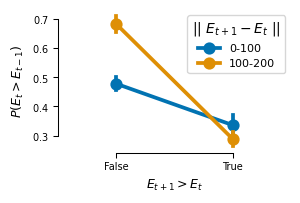

In [651]:
# ET_diff_bin_size = 200
ET_diff_bin_size = 100
distances_df.loc[:,'ET_diff_bin'] = (distances_df['ET_Distance'] // ET_diff_bin_size) + 1
grouped_distances = distances_df.groupby(['SubNum', 'is_pos', 'ET_diff_bin']).agg({
    'is_pos_Before': 'mean',
    'count': 'sum'
}).reset_index()

sns.pointplot(
    data=grouped_distances,
    x='is_pos',
    y='is_pos_Before',
    hue='ET_diff_bin',
    errorbar='se',
    palette='colorblind')

plt.xlabel(r'$E_{t+1} > E_{t}$')
plt.ylabel(r'$P(E_{t} > E_{t-1})$')

# remap legend labels without breaking color mapping
handles, labels = plt.gca().get_legend_handles_labels()
label_map = {}
for l in labels:
    bin_num = int(l)
    lower = (bin_num - 1) * ET_diff_bin_size
    upper = bin_num * ET_diff_bin_size
    label_map[l] = f'{lower}-{upper}'
plt.legend(handles, [label_map[l] for l in labels], title=r'|| $E_{t+1} - E_{t}$ ||')

sns.despine(trim=True)

plt.savefig(path_figs + 'P_ET_t_greater_ET_t_minus_1_vs_ET_t_plus_1_minus_ET_t.pdf', bbox_inches='tight', dpi=300)


In [642]:
grouped_distances

,SubNum,is_pos,ET_diff_bin,is_pos_Before,count
0,1,False,1,0.408696,115
1,1,False,2,0.631579,38
2,1,True,1,0.236842,76
3,1,True,2,0.370370,27
4,2,False,1,0.542373,118
5,2,False,2,0.750000,28
6,2,True,1,0.258427,89
7,2,True,2,0.210526,19
8,3,False,1,0.533981,103
9,3,False,2,0.838710,31


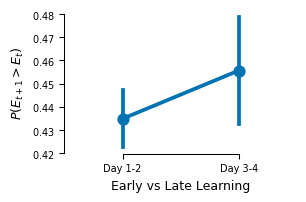

In [652]:
distances_df.loc[:, 'is_first_half'] = distances_df['day'].isin([1, 2])
# grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'is_first_half']).agg({
#     'is_pos': 'mean'
#     }).reset_index()

grouped_distances = distances_df.groupby(['SubNum', 'is_first_half']).agg({
    'is_pos': 'mean'
    }).reset_index()

sns.pointplot(data=grouped_distances, x='is_first_half', y='is_pos', errorbar = 'se', order=[True, False])
# sns.pointplot(data=grouped_distances, x='is_first_half', y='is_pos', errorbar = None, hue = 'SubNum')

plt.xticks([0, 1], ['Day 1-2', 'Day 3-4'])
plt.ylabel(r'$P(E_{t+1} > E_{t})$')
plt.xlabel('Early vs Late Learning')

sns.despine(trim=True)

stats.ttest_rel(grouped_distances[grouped_distances['is_first_half'] == True]['is_pos'], 
                grouped_distances[grouped_distances['is_first_half'] == False]['is_pos'])

plt.savefig(path_figs + 'P_ET_t_greater_ET_t_minus_1_early_vs_late_learning.pdf', bbox_inches='tight', dpi=300)


In [583]:
distances_df.loc[:, 'is_first_half'] = distances_df['day'].isin([1, 2])
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'is_first_half']).agg({
    'is_pos': 'mean'
    }).reset_index()

print(AnovaRM(grouped_distances, 'is_pos', 'SubNum', within=['ET_diff_bin', 'is_first_half']).fit())

                         Anova
                          F Value Num DF  Den DF Pr > F
-------------------------------------------------------
ET_diff_bin                2.7869 1.0000 10.0000 0.1260
is_first_half              0.2414 1.0000 10.0000 0.6338
ET_diff_bin:is_first_half  0.8990 1.0000 10.0000 0.3654



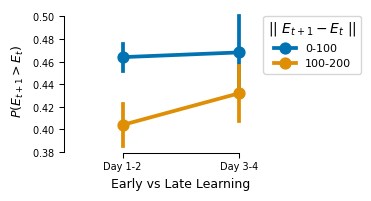

In [609]:
distances_df.loc[:, 'is_first_half'] = distances_df['day'].isin([1, 2])
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'is_first_half']).agg({
    'is_pos': 'mean',
    'count': 'sum'
    }).reset_index()

# Define consistent hue order (numeric bin order)
hue_order = sorted(grouped_distances['ET_diff_bin'].unique())


ax = sns.pointplot(grouped_distances, x='is_first_half', y='is_pos', errorbar = 'se', hue='ET_diff_bin', palette = 'colorblind', order=[True, False])
plt.xticks([0, 1], ['Day 1-2', 'Day 3-4'])
plt.xlabel('Early vs Late Learning')
plt.ylabel(r'$P(E_{t+1} > E_{t})$')

# Build legend from handles so colors match bins
bin_label_map = {
    b: f'{(b-1)*ET_diff_bin_size}-{b*ET_diff_bin_size}'
    for b in hue_order
}
handles, labels = ax.get_legend_handles_labels()
# labels are bin numbers as strings; map to interval text
ax.legend(
    handles,
    [bin_label_map[int(l)] for l in labels],
    title=r'|| $E_{t+1} - E_{t}$ ||',
    loc='upper right',
    bbox_to_anchor=(1.3, 1),
)

sns.despine(trim=True)


In [610]:
grouped_distances

,SubNum,ET_diff_bin,is_first_half,is_pos,count
0,1,1,False,0.345133,113
1,1,1,True,0.443299,97
2,1,2,False,0.366667,30
3,1,2,True,0.434783,46
4,2,1,False,0.432000,125
5,2,1,True,0.469388,98
6,2,2,False,0.407407,27
7,2,2,True,0.444444,27
8,3,1,False,0.462069,145
9,3,1,True,0.461538,65


In [368]:
# fig, axs = plt.subplots(1, 4, figsize=(12, 4), sharey=True)
# for et_bin, bindata in distances_df.groupby('ET_diff_bin'):
#     bindata = bindata.copy()
#     bindata['is_first_half'] = bindata['day'].isin([1, 2])
#     bindata['count'] = 1
#     grouped_data = bindata.groupby(['SubNum', 'is_first_half']).agg({'is_pos': 'mean',
#                                                                      'count': 'sum'}).reset_index()
#     sns.pointplot(data=grouped_data, x='is_first_half', y='is_pos', errorbar = 'se', ax=axs[et_bin - 1])
#     axs[et_bin - 1].set_title(f'ET in [{(et_bin - 1) * ET_diff_bin_size}, {et_bin * ET_diff_bin_size})')
# sns.despine(trim=True)

TtestResult(statistic=-0.9708626906241761, pvalue=0.35698378145986087, df=9)

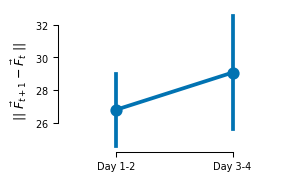

In [404]:
distances_df.loc[:, 'is_first_half'] = distances_df['day'].isin([1, 2])
# grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'is_first_half']).agg({
#     'Force_Distance': 'mean'
#     }).reset_index()

grouped_distances = distances_df.groupby(['SubNum', 'is_first_half']).agg({
    'Force_Distance': 'median'
    }).reset_index()

sns.pointplot(data=grouped_distances, x='is_first_half', y='Force_Distance', errorbar = 'se', order=[True, False])
plt.xticks([0, 1], ['Day 1-2', 'Day 3-4'])
plt.xlabel(None)
plt.ylabel(r'|| $\vec{F}_{t+1} - \vec{F}_{t}$ ||')
sns.despine(trim=True)

stats.ttest_rel(grouped_distances[grouped_distances['is_first_half'] == True]['Force_Distance'], 
                grouped_distances[grouped_distances['is_first_half'] == False]['Force_Distance'])


In [405]:
distances_df.loc[:, 'is_first_half'] = distances_df['day'].isin([1, 2])
grouped_distances = distances_df.groupby(['SubNum', 'ET_diff_bin', 'is_first_half']).agg({
    'Force_Distance': 'median'
    }).reset_index()

print(AnovaRM(grouped_distances, 'Force_Distance', 'SubNum', within=['ET_diff_bin', 'is_first_half']).fit())

                         Anova
                          F Value Num DF  Den DF Pr > F
-------------------------------------------------------
ET_diff_bin               47.8842 2.0000 18.0000 0.0000
is_first_half              2.9428 1.0000  9.0000 0.1204
ET_diff_bin:is_first_half  1.2304 2.0000 18.0000 0.3156



In [407]:
distances_df.columns

Index(['SubNum', 'Force_Distance', 'ET_Distance', 'is_pos', 'day', 'count',
       'ET_diff_bin', 'is_first_half'],
      dtype='object')